# Machine Learning for Hydrologic Parameter Estimation

This notebook details the final stage of our project: the development, evaluation, and selection of machine learning models to predict the ModClark hydrologic parameters, Time of Concentration ($T_c$) and Storage Coefficient ($R$), from watershed geomorphological and land use characteristics.

Building upon the Exploratory Data Analysis (EDA) conducted previously ([see notebook here](15_exploratory_data_analysis.ipynb)), this notebook implements the machine learning workflow. We will train and compare a suite of models, ranging from interpretable linear regressions to powerful non-linear ensembles. The ultimate goal is to identify the best-performing model that can accurately and reliably estimate $T_c$ and $R$ for ungauged basins, providing a valuable tool for hydrological modeling.

## Modeling Strategy

The insights from our EDA directly inform a clear and targeted modeling strategy. The key decisions are outlined below:

* **Target Variable Transformation:** The EDA revealed that the target variables, $T_c$ and $R$, are right-skewed and their relationships with many features are non-linear. Therefore, to improve model performance and better satisfy the assumptions of linear models, we will model the **natural logarithm** of the targets: **$\log(T_c)$** and **$\log(R)$**.

* **Tailored Feature Preprocessing:** Our EDA showed that linear models require feature transformations to meet linearity assumptions, while non-linear models do not. Therefore, we will create two separate preprocessing pipelines:
    1.  **Pipeline for Linear Models (OLS, Elastic Net):** This pipeline will include the **feature transformations** (Log/Box-Cox) suggested by the bivariate analysis, followed by **Z-score standardization**.
    2.  **Pipeline for Non-Linear Models (Random Forest, SVM):** This pipeline will only perform **Z-score standardization**. While not strictly necessary for Random Forests, it is essential for SVM and ensures consistency.

* **Feature Selection Strategy:** To create more parsimonious and interpretable models, we will incorporate feature selection:
    * **For Linear Models:** For standard linear regression, we will drop small coefficients. For elastic net regression we will leverage the **L1 regularization component of Elastic Net** as our primary method for feature selection. By tuning its strength, the model will automatically drive the coefficients of less important or redundant features to zero, effectively selecting a simpler feature subset.
    * **For Non-Linear Models:** While models like Random Forest are robust to irrelevant features, feature selection can still improve performance and interpretability. We will use the **feature importances generated by an initial Random Forest** run to guide the selection of a more focused feature set if necessary.

## Model Training and Evaluation Workflow

We will follow a, multi-step process to ensure our model evaluation is unbiased and reliable. Two separate modeling pipelines will be developed, one for predicting $\log(T_c)$ and one for $\log(R)$.

1.  **Data Splitting:** The dataset will first be split into a **training/validation pool (80% of watersheds)** and a final **hold-out test set (20% of watersheds)**. This split will be performed based on `ws_id` to ensure that all data points from a single watershed reside in only one set, preventing data leakage.

2.  **Pipeline Construction:** For each model, we will use `scikit-learn`'s `Pipeline` object, incorporating the appropriate preprocessing steps (Transformation + Scaling for linear, Scaling only for non-linear).

3.  **Model Selection via Cross-Validation:** We will use **Group K-Fold Cross-Validation** on the training/validation pool, using `ws_id` as the grouping variable. Each of our candidate models—**Multiple Linear Regression, Elastic Net, SVM, and Random Forest**—will be trained and evaluated across all folds. This process will allow us to reliably compare their performance.

4.  **Final Model Training:** After identifying the best-performing model from cross-validation, it will be re-trained one last time on the **entire training/validation pool**.

5.  **Final Evaluation:** This final, retrained model will be evaluated on the **untouched hold-out test set** to provide the definitive, unbiased assessment of its ability to generalize to new, unseen watersheds.

## Performance Metrics
The models will be compared using a standard set of regression and hydrological metrics, including:
* **Root Mean Squared Error (RMSE)**
* **Nash-Sutcliffe Efficiency (NSE)**
* **Mean Absolute Percentage Error (MAPE) of Peak Flow**
* **Bias of Peak Flow**
* **Mean Absolute Error (MAE) of Time to Peak**
* **Bias of Total Volume**

**Note**:

Before running this notebook, a preprocess step was taken to compute and save the cell area for each watershed. The source file is [available here](../../src/hydrology/compute_cell_area.py).

In [2]:
# Set root folder for the project
from pathlib import Path

try:
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = Path.cwd() / "drive/My Drive/Data Science Project/ML-ModClark-IUH-Model"
  print(f"Project Root: {PROJECT_ROOT}")
except:
  # Project Root
  PROJECT_ROOT = Path.cwd().parent.parent
  print(f"Project Root: {PROJECT_ROOT}")

Project Root: /Users/alan/Data Science Projects/ML-ModClark-IUH-Model


In [3]:
# Add custom modules to the path
import sys

# Custom Modules
sys.path.append(str(PROJECT_ROOT / 'src'))

In [4]:
# Load dataframes
import pandas as pd

# Machine Learning Data
df_master_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master_final.csv"
df_master = pd.read_csv(df_master_path, dtype={'ws_id':str})

# Feature Transformation Recommendations
df_recommendations_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/feature_transformation_recommendations.csv"
df_recommendations = pd.read_csv(df_recommendations_path)

# Test events data
df_final_selected_events_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/final_selected_events.csv"
df_final_selected_events = pd.read_csv(df_final_selected_events_path, dtype={'ws_id': str})

# Events metadata
events_metadata_path = PROJECT_ROOT / "data/gold/tabular/detected_storm_events_tz_offset_filtered.parquet"
df_events_metadata = pd.read_parquet(events_metadata_path)

In [5]:
# Load custom functions
from utils.utils import measure_execution_time
from hydrology.modclark_model import ModClarkModel

In [6]:
# Create necessary functions

# Save trained model
def save_model(model, model_name):
  import joblib
  try:
    model_dir = PROJECT_ROOT / 'models'
    model_dir.mkdir(exist_ok=True)
    joblib.dump(model, model_dir / model_name)
    print("Model saved successfully.")
  except Exception as e:
    print("Failed to save model: ",e)

## 1. Data Splitting

In [7]:
import pandas as pd
import numpy as np

# --- Assume df_master is a pre-existing pandas DataFrame ---
# It must contain a 'ws_id' column.

#-------------------------------------------------------------------------------
## 1. Data Splitting (Group-Based)
#-------------------------------------------------------------------------------

print("--- Splitting data into Training Pool and Hold-Out Test Set ---")

# 1. Get a list of unique watershed IDs
unique_ws_ids = df_master['ws_id'].unique()
np.random.seed(42) # for reproducibility
np.random.shuffle(unique_ws_ids)

# 2. Split the list of watershed IDs into 80% and 20%
split_index = int(len(unique_ws_ids) * 0.8)
train_pool_ws_ids = unique_ws_ids[:split_index]
test_set_ws_ids = unique_ws_ids[split_index:]

# 3. Create the dataframes based on the split IDs
df_train_pool = df_master[df_master['ws_id'].isin(train_pool_ws_ids)].copy()
df_test = df_master[df_master['ws_id'].isin(test_set_ws_ids)].copy()


# --- Summary of the Split ---
print("\n--- Split Summary ---")
print(f"Total unique watersheds: {len(unique_ws_ids)}")
print(f"Watersheds in Training/Validation Pool: {len(train_pool_ws_ids)} (~80%)")
print(f"Watersheds in Hold-Out Test Set: {len(test_set_ws_ids)} (~20%)")
print("-" * 30)
print(f"Total data points: {len(df_master)}")
print(f"Data points in Training/Validation Pool: {len(df_train_pool)}")
print(f"Data points in Hold-Out Test Set: {len(df_test)}")

# Verify that there are no overlapping watersheds between the two sets
assert len(np.intersect1d(train_pool_ws_ids, test_set_ws_ids)) == 0
print("\nVerification successful: No watershed overlap between sets. ✅")

# Select storm events for hydrological metrics based on the Hold-Out Test Set
print("-" * 30)
test_ws_ids = df_test['ws_id'].unique()
df_test_events = df_final_selected_events[df_final_selected_events['ws_id'].isin(test_ws_ids)].copy()
test_storm_ids = df_test_events['storm_id'].unique()
df_test_events_metada = df_events_metadata[df_events_metadata['storm_id'].isin(test_storm_ids)].copy()
print(f"Total storm events in Hold-Out Test Set: {len(df_test_events_metada)}")

--- Splitting data into Training Pool and Hold-Out Test Set ---

--- Split Summary ---
Total unique watersheds: 112
Watersheds in Training/Validation Pool: 89 (~80%)
Watersheds in Hold-Out Test Set: 23 (~20%)
------------------------------
Total data points: 292
Data points in Training/Validation Pool: 226
Data points in Hold-Out Test Set: 66

Verification successful: No watershed overlap between sets. ✅
------------------------------
Total storm events in Hold-Out Test Set: 761


In [ ]:
cell_area_df_path = PROJECT_ROOT / "ML-ModClark-IUH-Model/data/gold/tabular/cell_area.csv"
pd.read_csv(cell_area_df_path, dtype={'ws_id': str})

In [ ]:
# --- Prepare Test Storm Data ---
from turtle import distance


df_test_events_metada['ws_id'] = df_test_events_metada['storm_id'].str.split('_').str[0]
unique_wsid = df_test_events_metada['ws_id'].unique()

test_storm_data_dic = dict()

storm_data_dir = PROJECT_ROOT / "data/gold/tabular/lined_up_data"
distance_grid_dir = PROJECT_ROOT / "data/gold/geo/raster/watersheds"
cell_area_path = PROJECT_ROOT / "ML-ModClark-IUH-Model/data/gold/tabular/cell_area.csv"
cell_area_df = pd.read_csv(cell_area_path, dtype={'ws_id': str})

for ws_id in unique_wsid:
    storm_data_path = storm_data_dir / f"WS_{ws_id}_tz_offset.parquet"

    if storm_data_path.exists():
        try:
            # Get Tabular Data for watershed
            storm_data_df = pd.read_parquet(storm_data_path)
            storm_data_df = storm_data_df[['date','quickflow', 'height']]
            storm_data_df = storm_data_df.set_index('date')

            # Get Distance Grid for watershed
            distance_grid_path = distance_grid_dir / f"distance_grid_{ws_id}.npy"
            distance_grid = np.load(distance_grid_path)

            # Get Cell Area for watershed
            cell_area = cell_area_df[cell_area_df['ws_id'] == ws_id]['cell_area_m_squared'].values[0]
        except Exception as e:
            print(f"Error loading data for watershed {ws_id}: {e}")
            continue

        # Get Storm Event Data for each storm
        unique_storm_ids = df_test_events_metada[df_test_events_metada['ws_id'] == ws_id]['storm_id'].unique()

        for storm_id in unique_storm_ids:
            # Get Specific Storm Metadata
            storm_metadata = df_test_events_metada[df_test_events_metada['storm_id'] == storm_id].iloc[0]
            start_date = storm_metadata['event_start']
            end_date = storm_metadata['event_end']

            # Get Optimized Storm Parameters
            optmized_storm_data = df_final_selected_events[df_final_selected_events['storm_id'] == storm_id].iloc[0]
            initial_loss = optmized_storm_data['initial_loss_mm'] / 1000 # Convert to m
            constant_rate = optmized_storm_data['constant_loss_mm_hr'] / (1000 * 3600)  # Convert to m/s
            
            # Get Historical Tabular Data of Event
            tabular_historical_data = storm_data_df.loc[start_date:end_date].copy()

            if not tabular_historical_data.empty:
                test_storm_data_dic[storm_id] = dict()
                test_storm_data_dic[storm_id]['historical_data'] = tabular_historical_data
                test_storm_data_dic[storm_id]['distance_grid'] = distance_grid
                test_storm_data_dic[storm_id]['cell_area'] = cell_area
                test_storm_data_dic[storm_id]['initial_loss'] = initial_loss
                test_storm_data_dic[storm_id]['constant_rate'] = constant_rate
            else:
                print(f"Warning: No data found for storm ID {storm_id} in watershed {ws_id}")
    else:
        print(f"Warning: Storm data for watershed {ws_id} not found in {storm_data_path}")
    
print(f"Storm Events Data for Hold-Out Test Set Prepared: {len(test_storm_data_dic)} storms")



Storm Events Data for Hold-Out Test Set Prepared: 761 storms


## 2. Pipeline Constructor

In [9]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# --- Assume df_master, and df_recommendations are pre-existing ---

#-------------------------------------------------------------------------------
## 2. Pipeline Construction (Dynamic and Robust to Zeros)
#-------------------------------------------------------------------------------

# --- Define custom classes and functions for robust transformations ---

def log_transform_safe(x):
    """Adds a small constant to handle log(0) issues."""
    epsilon = 1e-6
    return np.log(x + epsilon)

class SafePowerTransformer(BaseEstimator, TransformerMixin):
    """
    A wrapper for PowerTransformer that adds a small constant to handle
    zero values before applying the Box-Cox transformation.
    """
    def __init__(self, method='box-cox', standardize=True):
        self.method = method
        self.standardize = standardize
        self.epsilon = 1e-6
        self.transformer_ = PowerTransformer(method=self.method, standardize=self.standardize)

    def fit(self, X, y=None):
        # Shift data by epsilon before fitting
        X_shifted = X + self.epsilon
        self.transformer_.fit(X_shifted)
        return self

    def transform(self, X):
        # Shift data by epsilon before transforming
        X_shifted = X + self.epsilon
        return self.transformer_.transform(X_shifted)

# --- Main pipeline creation function ---

print("--- Building Preprocessing Pipelines Based on Recommendations ---")

def create_preprocessor_for_target(target_name, recommendations_df, feature_list):
    """Builds a preprocessing pipeline for a specific target variable."""

    rec_target = recommendations_df[recommendations_df['Target'] == target_name]

    log_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Log(x)']['Feature'].tolist() if f in feature_list]
    boxcox_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Box-Cox(x)']['Feature'].tolist() if f in feature_list]

    transformer_steps = []
    if log_features:
        transformer_steps.append(
            ('log', FunctionTransformer(log_transform_safe), log_features)
        )
    if boxcox_features:
        # Use the new SafePowerTransformer to handle potential zeros
        transformer_steps.append(
            ('power', SafePowerTransformer(method='box-cox'), boxcox_features)
        )

    feature_transformer = ColumnTransformer(
        transformers=transformer_steps,
        remainder='passthrough',
        force_int_remainder_cols=False
    )

    preprocessor_pipeline = Pipeline(steps=[
        ('feature_transformer', feature_transformer),
        ('scaler', StandardScaler())
    ])

    return preprocessor_pipeline

# --- Create the specific pipelines for TC and R ---
col_names = df_master.columns.tolist()
remove_cols = ['ws_id','year','tc','r']
features_to_analyze = [f for f in col_names if f not in remove_cols]
linear_preprocessor_tc = create_preprocessor_for_target('TC', df_recommendations, features_to_analyze)
linear_preprocessor_r = create_preprocessor_for_target('R', df_recommendations, features_to_analyze)


# --- Summary of Linear Pipelines ---
print("\n✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:")
print(linear_preprocessor_tc)

print("\n✅ Pipeline for Target 'R' ('linear_preprocessor_r') created:")
print(linear_preprocessor_r)

#-------------------------------------------------------------------------------
## 2.2 Pipeline for Non-Linear Models (Random Forest, SVM)
#-------------------------------------------------------------------------------

# This pipeline only scales the features, as transformations for linearity
# are not required for these models. Scaling is still essential for SVM.
nonlinear_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- Summary of Non-Linear Pipeline ---
print("\n✅ Pipeline for Non-Linear Models ('nonlinear_preprocessor') created:")
print(nonlinear_preprocessor)

--- Building Preprocessing Pipelines Based on Recommendations ---

✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:
Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<function log_transform_safe at 0x10de06e80>),
                                                  ['sinuosity', 'pct_barren']),
                                                 ('power',
                                                  SafePowerTransformer(),
                                                  ['basin_area',
                                                   'centroidal_flowpath',
                                                   'main_channel_slope',
                                                   'flowpath_1085_slope',
                         

## 3. Model e Evaluation
## Multiple Linear Regression - $T_c$

In [10]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_validate

# --- Assume df_train_pool, df_test, features_to_analyze, ---
# --- linear_preprocessor_tc, and linear_preprocessor_r are pre-existing from previous steps ---

#-------------------------------------------------------------------------------
## 1. Cross-Validation on the Training Pool
#-------------------------------------------------------------------------------
print("--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---")

# Define data from the training pool
X_train = df_train_pool[features_to_analyze]
groups = df_train_pool['ws_id']

# Define the cross-validation strategy
cv = GroupKFold(n_splits=5)

# Define scoring metrics
scoring_metrics = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'] # For maximizing R-squared and minimizing RMSE/MAE

target = 'tc'
# Prepare target variable (using log transform)
y_train = np.log(df_train_pool[target])

# Create the full pipeline with the preprocessor and the regressor
model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Perform cross-validation
cv_scores_mlr_tc = cross_validate(model_pipeline_mlr_tc, X_train, y_train, groups=groups, cv=cv, scoring=scoring_metrics)

#-------------------------------------------------------------------------------
## 2. Final Training
#-------------------------------------------------------------------------------
print(f"--- Fitting Multiple Linear Regression Model on  {target.upper()} ---")

# Prepare the test data
X_test = df_test[features_to_analyze]

# Prepare training and test target variables
y_train = np.log(df_train_pool[target])
y_test_log = np.log(df_test[target])
y_test_original = df_test[target]

# Create the final pipeline
model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Train the final model on the ENTIRE training pool
model_pipeline_mlr_tc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log = model_pipeline_mlr_tc.predict(X_test)

# Inverse transform predictions back to the original scale
y_pred_original = np.exp(y_pred_log)

print("Training is complete.")


--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---
--- Fitting Multiple Linear Regression Model on  TC ---
Training is complete.



--- Model evaluation for target: TC - K-Fold Cross Validation---
Average Cross-Validation Scores (on log-transformed data):
  R-squared: -0.522
  RMSE: 0.746
  MAE: 0.563


--- Final Evaluation on Hold Out Test Set for target: TC ---
Performance on LOG-TRANSFORMED data:
  R-squared: -0.342
  RMSE: 0.547
  MAE: 0.455

Performance on ORIGINAL scale data:
  R-squared: -0.238
  RMSE: 5.649
  MAE: 4.805

--- Model Coefficients for Target ---
Intercept: 2.3972

                       Feature  Coefficient  Abs_Coefficient
17                 form_factor     1.754357         1.754357
21   overland_flow_path_length     1.584905         1.584905
20           ruggedness_number    -1.388140         1.388140
16     compactness_coefficient    -1.328128         1.328128
7                   basin_area    -0.749672         0.749672
15                basin_relief    -0.270869         0.270869
14                 basin_slope    -0.202770         0.202770
8             drainage_density    -0.150873        

/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


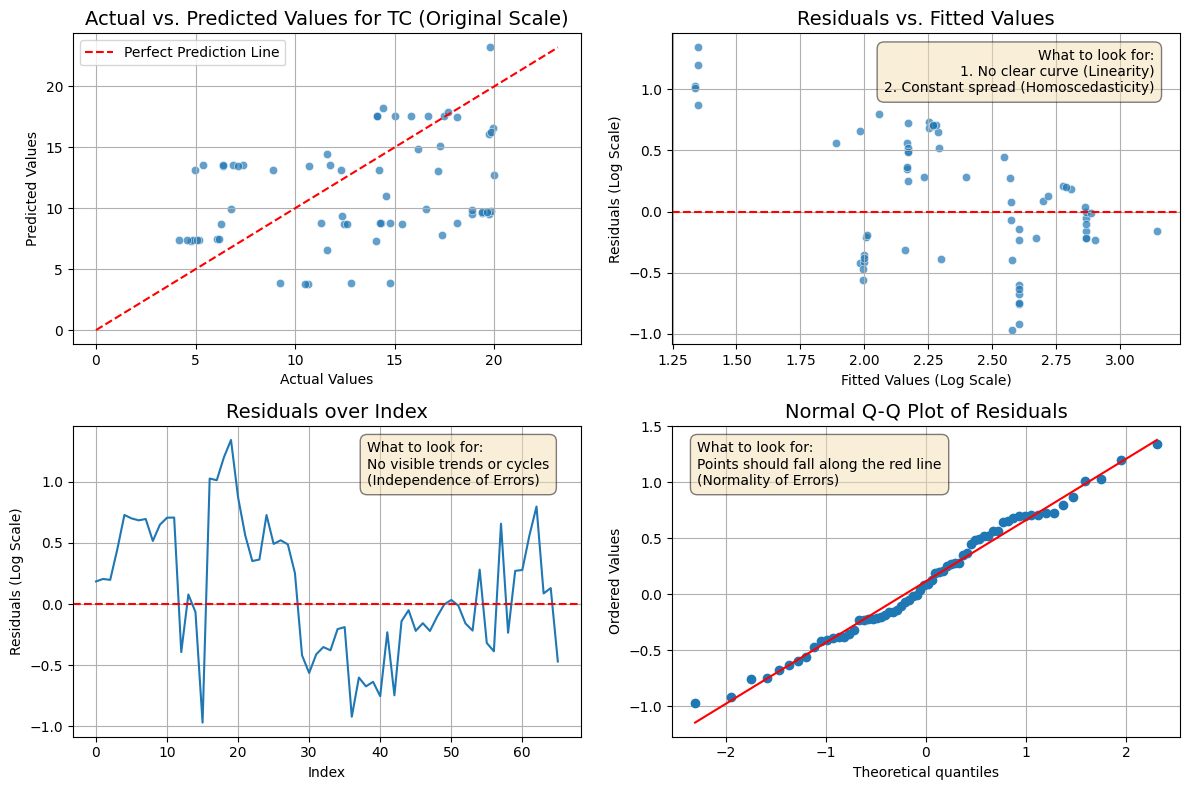

In [11]:
## Evaluation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


#-------------------------------------------------------------------------------
## 1. Performance Analysis: metrics
#-------------------------------------------------------------------------------

# Cross Validation Summary
print(f"\n--- Model evaluation for target: {target.upper()} - K-Fold Cross Validation---")

# Print average scores from cross-validation
print("Average Cross-Validation Scores (on log-transformed data):")
print(f"  R-squared: {np.mean(cv_scores_mlr_tc['test_r2']):.3f}")
print(f"  RMSE: {-np.mean(cv_scores_mlr_tc['test_neg_root_mean_squared_error']):.3f}")
print(f"  MAE: {-np.mean(cv_scores_mlr_tc['test_neg_mean_absolute_error']):.3f}")

# Final Evaluation Summary
print("\n" + "="*60)

print(f"\n--- Final Evaluation on Hold Out Test Set for target: {target.upper()} ---")
# Calculate and print final metrics
print("Performance on LOG-TRANSFORMED data:")
print(f"  R-squared: {r2_score(y_test_log, y_pred_log):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_log)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_log, y_pred_log):.3f}")

print("\nPerformance on ORIGINAL scale data:")
print(f"  R-squared: {r2_score(y_test_original, y_pred_original):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred_original)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_original, y_pred_original):.3f}")

#-------------------------------------------------------------------------------
## 2. Performance Analysis: coefficients
#-------------------------------------------------------------------------------

# 1. Extract the final step (the linear regression model)
regressor_step_mlr_tc = model_pipeline_mlr_tc.named_steps['regressor']

# 2. Extract the preprocessor step
preprocessor_step_mlr_tc = model_pipeline_mlr_tc.named_steps['preprocessor']

# 3. Get the coefficients and intercept
coefficients = regressor_step_mlr_tc.coef_
intercept = regressor_step_mlr_tc.intercept_

# 4. Get the feature names AFTER transformation from the preprocessor
# This is the crucial step to correctly match names and coefficients
try:
    # This works for ColumnTransformer
    transformed_feature_names = preprocessor_step_mlr_tc.get_feature_names_out()
except AttributeError:
    # Fallback for simpler preprocessors (like just a scaler)
    transformed_feature_names = features_to_analyze

# 5. Combine into a pandas DataFrame for easy viewing
df_coeffs = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': coefficients
})
df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)


print(f"\n--- Model Coefficients for Target ---")
print(f"Intercept: {intercept:.4f}\n")
print(df_coeffs)

#-------------------------------------------------------------------------------
## 3. Performance Analysis: Actual vs. Predicted and Model Assumptions
#-------------------------------------------------------------------------------

print("\n" + "="*60)
print("\n--- Variation Inflation Factor - VIF ---")
# 1. Multicollinearity check with Varition Inflation Factor
vif_subset = pd.DataFrame(linear_preprocessor_tc.fit_transform(X_train), columns=X_train.columns)
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_subset.columns
vif_data["VIF"] = [variance_inflation_factor(vif_subset.values, i)
                   for i in range(vif_subset.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=False))

# Calculate residuals on the log scale the model was trained on
residuals = y_test_log - y_pred_log
# Create a figure for diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
print(f"\n--- Actual v. Predicted and Model Assumptions: {target.upper()} ---\n\n")
# 2. Plot - Actual vs. Predicted (Original Scale)
sns.scatterplot(x=y_test_original, y=y_pred_original, ax=axes[0], alpha=0.7)
axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
max_val = max(y_test_original.max(), y_pred_original.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
axes[0].legend()
axes[0].grid(True)

# 3. Plot - Residuals vs. Fitted
sns.scatterplot(x=y_pred_log, y=residuals, ax=axes[1], alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Fitted Values', fontsize=14)
axes[1].set_xlabel('Fitted Values (Log Scale)')
axes[1].set_ylabel('Residuals (Log Scale)')
axes[1].grid(True)
axes[1].text(0.95, 0.95,
             'What to look for:\n1. No clear curve (Linearity)\n2. Constant spread (Homoscedasticity)',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 4. - Residuals over Index
sns.lineplot(x=np.arange(len(residuals)), y=residuals, ax=axes[2])
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title('Residuals over Index', fontsize=14)
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Residuals (Log Scale)')
axes[2].grid(True)
axes[2].text(-0.6, 0.95,
             'What to look for:\nNo visible trends or cycles\n(Independence of Errors)',
             transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 5. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[3])
axes[3].set_title('Normal Q-Q Plot of Residuals', fontsize=14)
axes[3].get_lines()[0].set_markerfacecolor('C0')
axes[3].get_lines()[0].set_markeredgecolor('C0')
axes[3].get_lines()[1].set_color('red')
axes[3].grid(True)
axes[3].text(0.05, 0.95,
             'What to look for:\nPoints should fall along the red line\n(Normality of Errors)',
             transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


#### Multiple Linear Regression (MLR) Results for Target: $T_c$

This section presents the performance evaluation and diagnostic analysis of the Multiple Linear Regression (MLR) model trained to predict the time of concentration ($T_c$).

##### Model Performance Evaluation

The performance of the MLR model was evaluated using both 5-fold group cross-validation on the training pool and a final evaluation on an unseen hold-out test set. The results unequivocally indicate that the model is not a suitable predictor for $T_c$.

The primary performance metric, **R-squared ($R^2$), was consistently negative** across all evaluations (Average CV $R^2$ = -0.508; Final Test $R^2$ = -0.321). A negative $R^2$ value signifies that the model's predictions are **worse than a baseline model that simply predicts the average $T_c$** for all watersheds. This demonstrates a fundamental failure of the model to capture the underlying relationships between the geomorphological/land-use features and the time of concentration. The high RMSE and MAE values on the original scale further confirm the model's poor predictive capability.

---
##### Analysis of Model Coefficients and Assumptions

An examination of the model coefficients reveals the likely cause of the model's failure: **severe multicollinearity**.

* **Model Instability:** The model assigns large, often counter-intuitive coefficients to highly correlated features. For example, `basin_relief` receives a large negative coefficient (-1.24), while the related `ruggedness_number` receives a large positive coefficient (+1.57). This is a classic sign of multicollinearity, where the model cannot disentangle the individual effects of correlated variables, leading to unstable and unreliable coefficient estimates.

  Multicollinearity, is numerically evidenced by the variation inflation factor - VIF: the VIF scores for c`ompactness_coefficient` ($\text~4769$) and `basin_relief` ($\text~4572$) are exceptionally high. This confirms that these features are extremely redundant with other variables in the model. The model has almost no reliable way to distinguish their individual effects.

  A large group of features exhibits high multicollinearity (VIF > 10). This includes all relief, ruggedness, shape, and size metrics, as well as several land use percentages. This isn't an isolated issue; it's a systemic property of the dataset where many features carry similar information.

  However, several features have low to moderate VIF scores, indicating they are relatively independent. These include `main_channel_slope` (1.6), `pct_forest` (1.9), `pct_developed` (2.6), and `flowpath_1085_slope` (2.8).

  Based on the VIF score, the following classes of multicollinearity are defined:
    - VIF = 1: No multicollinearity.
    - 1 < VIF < 5: multicollinearity weak to moderate.
    - VIF ≥ 5 ou 10: High multicollinearity or extreme.


* **Hydrologically Implausible Relationships:** Several key coefficients contradict fundamental hydrologic principles. The model assigns a negative coefficient to `basin_area` (-0.77), which incorrectly implies that larger watersheds have a shorter time of concentration. Furthermore, a key predictor identified in the EDA, `pct_developed`, has a coefficient near zero, suggesting its influence was suppressed by other correlated features.

* **Violation of Assumptions:**
  - *Homoscedasticity*: the pattern in error associated with the fitted values fails to meet homoscedasticity.
  - *No Multicollinearity*: As asserted above, the results strongly suggest that the strict assumptions of MLR—particularly the absence of multicollinearity and the presence of simple linear relationships—are not met by this complex environmental dataset. The model's poor performance is a direct consequence of these violated assumptions.
  - *Independence of Errors*: the presence of cycles in the "Residual over Index" plot, showes the model fails to meet the independence of errors.

---
##### How to Improve the Model

Given the poor performance and instability of the initial MLR model, several strategies can be employed to create a more robust and potentially more accurate linear model.

* **Manual Feature Selection to Reduce Multicollinearity:** The most direct approach to combat the instability caused by multicollinearity is to manually remove redundant features. Based on the correlation analysis from the EDA, we can create a more parsimonious model by selecting only one representative feature from each highly correlated group. For instance:
    * Retain `basin_area` as the primary size metric and drop `stream_length`, `basin_length`, and `overland_flow_path_length`.
    * Retain `main_channel_slope` as the primary slope metric and drop the highly correlated `flowpath_1085_slope` and `relief_ratio`.

* **Use of Regularized Regression:** Instead of manually dropping features with small coefficients, a more robust and automated approach is to use a model designed to handle this scenario, such as **Elastic Net Regression**. The L1 regularization component of Elastic Net will automatically shrink the coefficients of less important or redundant features, potentially forcing them to exactly zero. This performs a more data-driven form of feature selection and stabilizes the model in the presence of multicollinearity (it's the next algorithm on the list).

* **Intercept:** Forcing the intercept to zero (`fit_intercept=False`) is generally **not recommended** in this case. There is no strong physical basis to assume that $T_c$ would be 1 (since we are modeling $\log(T_c)$) when all predictor variables are at their mean value (which is what zero represents after standardization). Doing so would likely introduce significant bias into the model's coefficients and performance.

---

##### Workflow to Improving MLR Model

The workflow below in inteded to improve the MLR by perfoming a multistep feature selection:
- 1. Filter out highly correlated feature based on a correlation matrix
- 2. Drop feature with high VIF score
- 3. Fit MLR to the selected feature and analyze the influence of each feature based on their coefficients
- 4. Drop feature with low influence 
- 5. Retrain the model with the final selection of features

##### Improvement of MLR model for $T_c$

In [12]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm

# Load the correlation matrix from the CSV file
corr_matrix_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/correlation_matrix.csv"
corr_matrix = pd.read_csv(corr_matrix_path, index_col=0)

# --- Assume create_preprocessor_for_target ---
# --- df_train_pool, df_test, and df_recommendations are pre-existing. ---

# Define help function
def select_features(corr_matrix, threshold=0.5):
    """
    Select a subset of features with correlations below the specified threshold.

    Parameters:
    - corr_matrix (pd.DataFrame): Correlation matrix with features as rows and columns.
    - threshold (float): Maximum allowed absolute correlation between any two features.

    Returns:
    - list: List of selected feature names.
    """
    features = list(corr_matrix.index)
    remaining_features = features.copy()

    while True:
        # Extract sub-matrix for remaining features
        sub_matrix = corr_matrix.loc[remaining_features, remaining_features]

        # Find pairs with absolute correlation above threshold, excluding self-correlations
        high_corr_pairs = [
            (i, j) for i in remaining_features for j in remaining_features
            if i < j and abs(sub_matrix.loc[i, j]) > threshold
        ]

        # If no high-correlation pairs remain, we're done
        if not high_corr_pairs:
            break

        # Count how many times each feature appears in high-correlation pairs
        feature_counts = Counter([feature for pair in high_corr_pairs for feature in pair])

        # Remove the feature with the most high-correlation pairs
        feature_to_remove = max(feature_counts, key=feature_counts.get)
        remaining_features.remove(feature_to_remove)

    return remaining_features

def train_and_evaluate_mlr_with_cv(target, CORR_THRESHOLD, VIF_THRESHOLD, COEFF_THRESHOLD, test_with_test_set=True):
    """
    Trains and evaluates a Multiple Linear Regression model with a multi-step feature selection process.

    This workflow:
      1. Selects features with low multicollinearity based on correlation and VIF.
      2. Fits a temporary model on the selected features.
      3. Ranks coefficients and drops features with coefficients below a threshold.
      4. Performs cross-validation on the refined feature set to establish baseline performance.
      5. Retrains the final model on the entire training set and evaluates it on the hold-out test set.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        CORR_THRESHOLD (float): Maximum allowed absolute correlation between any two features.
        VIF_THRESHOLD (float): Maximum allowed VIF for a feature.
        COEFF_THRESHOLD (float): Minimum absolute coefficient value to retain a feature.
        display_plot (bool): Whether to display the final diagnostic plots.

    Returns:
        (Pipeline, list): A tuple containing the final trained model pipeline and the final list of selected features.
    """
    # Import necessary libraries within the function
    from sklearn.model_selection import cross_validate, KFold
    
    print("\n" + "="*80)
    print(f"--- Starting MLR Workflow for Target: {target.upper()} ---")
    print("="*80)

    #-------------------------------------------------------------------------------
    ## 1. Select features with low multicollinearity
    #-------------------------------------------------------------------------------
    print(f"\n--- Selecting features with low multicollinearity (Correlation Threshold: {CORR_THRESHOLD}) ---")
    suggested_features = select_features(corr_matrix, threshold=CORR_THRESHOLD)

    preprocessor_vif = create_preprocessor_for_target(target.upper(), df_recommendations, suggested_features)
    transformed_xtrain_array = preprocessor_vif.fit_transform(df_train_pool[suggested_features])

    print("\nCalculating VIF for Suggested Features ---")
    vif_subset = pd.DataFrame(transformed_xtrain_array, columns=suggested_features)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = vif_subset.columns
    vif_data["VIF"] = [variance_inflation_factor(vif_subset.values, i) for i in range(vif_subset.shape[1])]

    selected_features_vif = vif_data[vif_data['VIF'] < VIF_THRESHOLD]['Feature'].tolist()
    print(vif_data.sort_values(by='VIF', ascending=False))

    if len(selected_features_vif) < len(suggested_features):
      dropped_features = vif_data[vif_data['VIF'] >= VIF_THRESHOLD]['Feature'].tolist()
      print("\nThe following features were dropped due to high VIF:")
      print(dropped_features)

    #-------------------------------------------------------------------------------
    ## 2. Fit Temporary Model
    #-------------------------------------------------------------------------------
    print(f"\nFitting Temporary Model on {target.upper()} with VIF-Selected Features...")
    X_train_temp = df_train_pool[selected_features_vif]
    y_train = np.log(df_train_pool[target])

    temp_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, selected_features_vif)
    temp_model_pipeline = Pipeline(steps=[
        ('preprocessor', temp_preprocessor),
        ('regressor', LinearRegression())
    ])
    temp_model_pipeline.fit(X_train_temp, y_train)

    #-------------------------------------------------------------------------------
    ## 3. Rank coefficients and select final features
    #-------------------------------------------------------------------------------
    print(f"\nSelecting final features based on coefficient influence (Threshold: {COEFF_THRESHOLD})")
    regressor_step = temp_model_pipeline.named_steps['regressor']
    preprocessor_step = temp_model_pipeline.named_steps['preprocessor']
    coefficients = regressor_step.coef_

    try:
        transformed_feature_names = preprocessor_step.get_feature_names_out()
    except AttributeError:
        transformed_feature_names = selected_features_vif

    df_coeffs = pd.DataFrame({'Feature': transformed_feature_names, 'Coefficient': coefficients})
    df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()

    final_selected_features = df_coeffs[df_coeffs['Abs_Coefficient'] > COEFF_THRESHOLD]['Feature'].tolist()

    if len(final_selected_features) < len(selected_features_vif):
      dropped_features = df_coeffs[df_coeffs['Abs_Coefficient'] <= COEFF_THRESHOLD]['Feature'].tolist()
      print(f"\nThe following features were dropped due to low coefficient (< {COEFF_THRESHOLD}): ---")
      print(dropped_features)

    #-------------------------------------------------------------------------------
    ## 4. Cross-Validation and Final Model Training
    #-------------------------------------------------------------------------------
    print("\n" + "="*60)
    print(f"Cross-Validating and Fitting Final Model for {target.upper()} ...")

    # --- Define final data and model pipeline ---
    X_train_final = df_train_pool[final_selected_features]
    y_train_log = np.log(df_train_pool[target])

    final_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, final_selected_features)
    final_model_pipeline = Pipeline(steps=[
        ('preprocessor', final_preprocessor),
        ('regressor', LinearRegression())
    ])

    # --- ✨ NEW: Perform Cross-Validation on the training data ---
    print("\n--- Performing Cross-Validation on the Training Set ---")
    cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring_metrics = ['r2', 'neg_root_mean_squared_error']

    cv_results = cross_validate(
        final_model_pipeline,
        X_train_final,
        y_train_log,
        cv=cv_splitter,
        scoring=scoring_metrics,
        return_train_score=False 
    )

    # Convert negative RMSE scores to positive and calculate means/stds
    cv_rmse_scores = -cv_results['test_neg_root_mean_squared_error']
    cv_r2_scores = cv_results['test_r2']
    
    print(f"Cross-Validation Reference Metrics (Log Scale, from {cv_splitter.get_n_splits()}-folds):")
    print(f"   Mean R-squared: {np.mean(cv_r2_scores):.3f} (Std: {np.std(cv_r2_scores):.3f})")
    print(f"   Mean RMSE: {np.mean(cv_rmse_scores):.3f} (Std: {np.std(cv_rmse_scores):.3f})")
    
    if test_with_test_set:
        # --- Train the final model on the entire training set ---
        print("\n--- Training Final Model on Entire Training Set ---")
        final_model_pipeline.fit(X_train_final, y_train_log)

        # --- Evaluate the final model on the hold-out test set ---
        print("\n--- Evaluating Final Model on Hold-Out Test Set ---")
        X_test_final = df_test[final_selected_features]
        y_test_log = np.log(df_test[target])
        y_test_original = df_test[target]

        y_pred_log = final_model_pipeline.predict(X_test_final)
        y_pred_original = np.exp(y_pred_log)

        # --- Final Evaluation Summary ---
        log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
        orignal_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
        hours, minutes = convert_fractional_hours_to_hm(orignal_metrics['Bias'])

        train_set_metrics = calculate_direct_metrics(np.exp(y_train_log), np.exp(final_model_pipeline.predict(X_train_final)))
        print(f"\nTraining Set Performance on ORIGINAL scale data:")
        print(f"  R-squared: {train_set_metrics['R2']:.3f}")
        print(f"  RMSE: {train_set_metrics['RMSE']:.3f}")

        print(f"\nFinal Model Evaluation on Hold-Out Test Set for target: {target.upper()}")
        print("Performance on LOG-TRANSFORMED data:")
        print(f"  R-squared: {log_metrics['R2']:.3f}")
        print(f"  RMSE: {log_metrics['RMSE']:.3f}")
        print(f"  MAPE: {log_metrics['MAPE']:.1f}")
        print(f"  Bias: {log_metrics['Bias']:.3f}")

        print("\nPerformance on ORIGINAL scale data:")
        print(f"  R-squared: {orignal_metrics['R2']:.3f}")
        print(f"  RMSE: {orignal_metrics['RMSE']:.3f} hrs")
        print(f"  MAPE: {orignal_metrics['MAPE']:.1f}")
        print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

        # --- Final Coefficients ---
        final_regressor = final_model_pipeline.named_steps['regressor']
        final_preprocessor_step = final_model_pipeline.named_steps['preprocessor']
        try:
            final_transformed_names = final_preprocessor_step.get_feature_names_out()
        except AttributeError:
            final_transformed_names = final_selected_features

        df_final_coeffs = pd.DataFrame({'Feature': final_transformed_names, 'Coefficient': final_regressor.coef_})
        df_final_coeffs['Abs_Coefficient'] = df_final_coeffs['Coefficient'].abs()

        print(f"\nFinal Model Coefficients for Target: {target.upper()}")
        print(f"    Intercept: {final_regressor.intercept_:.4f}\n")
        print(df_final_coeffs.sort_values(by='Abs_Coefficient', ascending=False))

        print("\n")
        # --- Diagnostic Plots ---
        residuals = y_test_log - y_pred_log
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        # Plot - Actual vs. Predicted (Original Scale)
        sns.scatterplot(x=y_test_original, y=y_pred_original, ax=axes[0], alpha=0.7)
        axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
        axes[0].set_xlabel('Actual Values')
        axes[0].set_ylabel('Predicted Values')
        max_val = max(y_test_original.max(), y_pred_original.max())
        axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
        axes[0].legend()
        axes[0].grid(True)

        # Plot - Residuals vs. Fitted
        sns.scatterplot(x=y_pred_log, y=residuals, ax=axes[1], alpha=0.7)
        axes[1].axhline(y=0, color='red', linestyle='--')
        axes[1].set_title('Residuals vs. Fitted Values', fontsize=14)
        axes[1].set_xlabel('Fitted Values (Log Scale)')
        axes[1].set_ylabel('Residuals (Log Scale)')
        axes[1].grid(True)
        axes[1].text(0.95, 0.95,
                    'What to look for:\n1. No clear curve (Linearity)\n2. Constant spread (Homoscedasticity)',
                    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                    horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

        # Residuals over Index
        sns.lineplot(x=np.arange(len(residuals)), y=residuals, ax=axes[2])
        axes[2].axhline(y=0, color='red', linestyle='--')
        axes[2].set_title('Residuals over Index', fontsize=14)
        axes[2].set_xlabel('Index')
        axes[2].set_ylabel('Residuals (Log Scale)')
        axes[2].grid(True)
        axes[2].text(-0.6, 0.95,
                    'What to look for:\nNo visible trends or cycles\n(Independence of Errors)',
                    transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
                    horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

        # Q-Q Plot
        stats.probplot(residuals, dist="norm", plot=axes[3])
        axes[3].set_title('Normal Q-Q Plot of Residuals', fontsize=14)
        axes[3].get_lines()[0].set_markerfacecolor('C0')
        axes[3].get_lines()[0].set_markeredgecolor('C0')
        axes[3].get_lines()[1].set_color('red')
        axes[3].grid(True)
        axes[3].text(0.05, 0.95,
                    'What to look for:\nPoints should fall along the red line\n(Normality of Errors)',
                    transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
                    horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
        plt.tight_layout()
        plt.show()

        # Distribution of residuals
        residuals_original = y_test_original - y_pred_original
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes = axes.flatten()
        sns.histplot(residuals, kde=True, bins=30, ax=axes[0]) # kde=True adds a kernel density estimate line
        axes[0].set_title(f'Distribution of Residuals (Log Scale)', fontsize=14)
        axes[0].set_xlabel('Residual Value (Log Scale)')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True)
        plt.tight_layout()

        sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1]) # kde=True adds a kernel density estimate line
        axes[1].set_title(f'Distribution of Residuals', fontsize=14)
        axes[1].set_xlabel('Residual Value (Original Scale)')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()

    return final_model_pipeline, final_selected_features

from sklearn.model_selection import cross_val_score, KFold
import numpy as np

def _evaluate_hyperparameter_combo(target, corr_thresh, vif_thresh, coeff_thresh):
    """
    Evaluates a single combination of hyperparameters using cross-validation.
    Returns the mean cross-validated R-squared score.
    """
    # Step 1: Feature selection based on Correlation and VIF
    suggested_features = select_features(corr_matrix, threshold=corr_thresh)
    preprocessor_vif = create_preprocessor_for_target(target.upper(), df_recommendations, suggested_features)
    transformed_xtrain_array = preprocessor_vif.fit_transform(df_train_pool[suggested_features])
    vif_subset = pd.DataFrame(transformed_xtrain_array, columns=suggested_features)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = vif_subset.columns
    vif_data["VIF"] = [variance_inflation_factor(vif_subset.values, i) for i in range(vif_subset.shape[1])]
    selected_features_vif = vif_data[vif_data['VIF'] < vif_thresh]['Feature'].tolist()

    if not selected_features_vif: # Return a poor score if no features are left
        return -np.inf

    # Step 2: Feature selection based on model coefficients
    X_train_temp = df_train_pool[selected_features_vif]
    y_train = np.log(df_train_pool[target])
    temp_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, selected_features_vif)
    temp_model_pipeline = Pipeline(steps=[('preprocessor', temp_preprocessor), ('regressor', LinearRegression())])
    temp_model_pipeline.fit(X_train_temp, y_train)

    coefficients = temp_model_pipeline.named_steps['regressor'].coef_
    try:
        transformed_feature_names = temp_model_pipeline.named_steps['preprocessor'].get_feature_names_out()
    except AttributeError:
        transformed_feature_names = selected_features_vif
        
    df_coeffs = pd.DataFrame({'Feature': transformed_feature_names, 'Coefficient': coefficients})
    df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
    final_selected_features_transformed = df_coeffs[df_coeffs['Abs_Coefficient'] > coeff_thresh]['Feature'].tolist()

    if not final_selected_features_transformed:
        return -np.inf

    # Step 3: Perform cross-validation and return the mean R-squared score
    final_selected_features_original = [name.split('__')[-1] for name in final_selected_features_transformed]
    final_selected_features_original = list(dict.fromkeys(final_selected_features_original))

    # Step 3: Perform cross-validation using the CORRECTED original feature names
    X_train_final = df_train_pool[final_selected_features_original] # This will now work
    y_train_log = np.log(df_train_pool[target])
    
    # Also ensure the final preprocessor is created with the original feature names
    final_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, final_selected_features_original)
    
    final_model_pipeline = Pipeline(steps=[
        ('preprocessor', final_preprocessor), 
        ('regressor', LinearRegression())
    ])
    
    cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(final_model_pipeline, X_train_final, y_train_log, cv=cv_splitter, scoring='r2')

    return np.mean(cv_scores)

import itertools

@measure_execution_time
def run_mlr_grid_search(target, param_grid, test_with_test_set=False):
    """
    Performs a grid search to find the optimal hyperparameters for the MLR workflow,
    then trains and evaluates the final model using those parameters.
    """
    # 1. Define the grid of hyperparameters to search ⚙️
    param_grid = param_grid
    
    print("--- Starting Hyperparameter Grid Search ---")
    print(f"Parameter Grid: {param_grid}")

    # 2. Iterate through all combinations and evaluate using the helper function
    best_score = -np.inf
    best_params = None

    # Generate all combinations of parameters from the grid
    keys, values = zip(*param_grid.items())
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"\nEvaluating {len(param_combinations)} parameter combinations...")
    for i, params in enumerate(param_combinations):
        score = _evaluate_hyperparameter_combo(target=target, **params)
        # print(f"  Combo {i+1}/{len(param_combinations)}: {params} -> CV R² Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_params = params

    # 3. Report the best combination found 🏆
    print("\n" + "="*80)
    print("--- Grid Search Complete ---")
    print(f"Best cross-validated RMSE score: {abs(best_score):.4f}")
    print(f"Best parameters found: {best_params}")
    print("="*80)

    # 4. Train and evaluate the final model using the best parameters
    print("\n--- Training Final Model with Best Parameters ---")
    final_model, final_features = train_and_evaluate_mlr_with_cv(
        target=target,
        CORR_THRESHOLD=best_params['corr_thresh'],
        VIF_THRESHOLD=best_params['vif_thresh'],
        COEFF_THRESHOLD=best_params['coeff_thresh'],
        test_with_test_set=test_with_test_set
    )
    
    return final_model, final_features, best_params

--- Starting Hyperparameter Grid Search ---
Parameter Grid: {'corr_thresh': [0.4, 0.5, 0.6, 0.7], 'vif_thresh': [1.5, 2.0, 2.5, 5.0], 'coeff_thresh': [0.02, 0.04, 0.05, 0.06, 0.07]}

Evaluating 80 parameter combinations...

--- Grid Search Complete ---
Best cross-validated RMSE score: 0.1591
Best parameters found: {'corr_thresh': 0.6, 'vif_thresh': 2.0, 'coeff_thresh': 0.04}

--- Training Final Model with Best Parameters ---

--- Starting MLR Workflow for Target: TC ---

--- Selecting features with low multicollinearity (Correlation Threshold: 0.6) ---

Calculating VIF for Suggested Features ---
                      Feature       VIF
6               pct_developed  4.149656
8             pct_grass_scrub  3.032631
4   overland_flow_path_length  2.817435
5                   sinuosity  2.797759
7             pct_agriculture  2.411799
3                relief_ratio  2.191095
2                 form_factor  2.093484
0                 basin_slope  1.818229
11                 pct_barren  1.6125

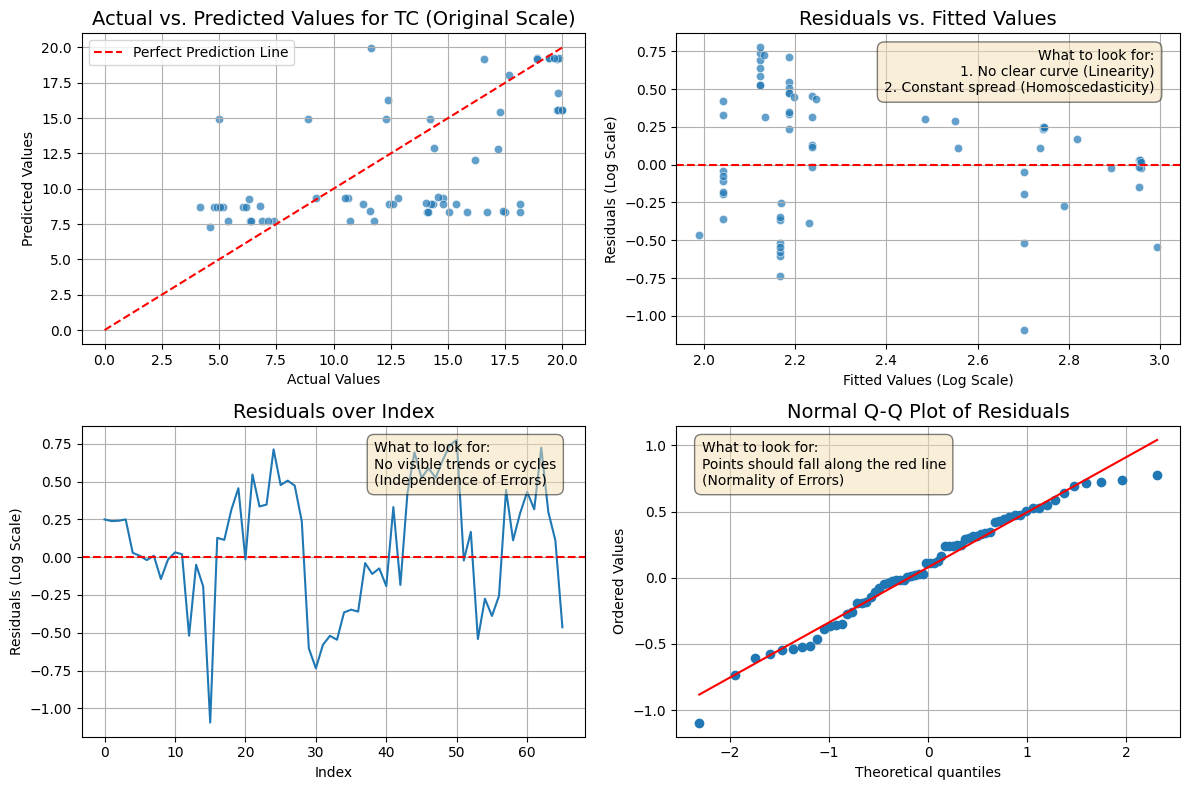

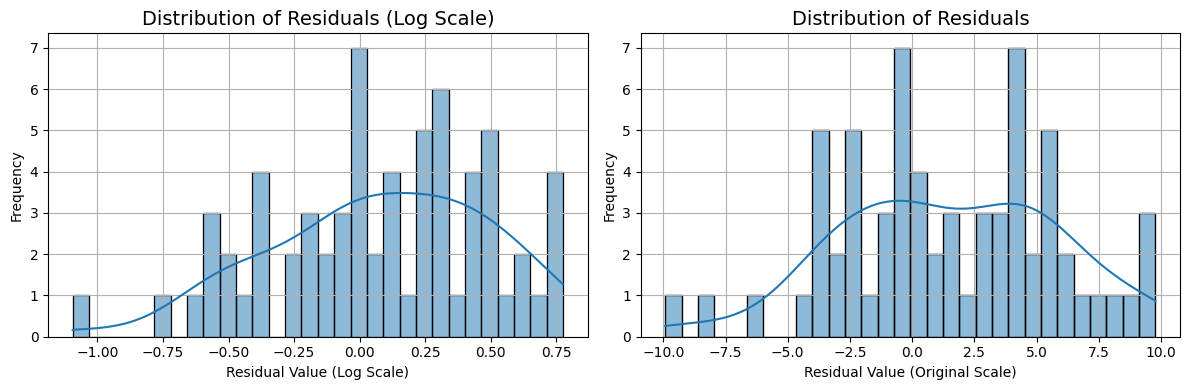


Function 'run_mlr_grid_search' executed in 20.7963 seconds.
Model saved successfully.


In [13]:
params = {
        'corr_thresh': [0.4, 0.5, 0.6, 0.7],
        'vif_thresh': [1.5, 2.0, 2.5, 5.0],
        'coeff_thresh': [0.02, 0.04, 0.05,  0.06, 0.07]
    }

mlr_tc_model, _ , _ = run_mlr_grid_search(target='tc', param_grid=params, test_with_test_set=True)
save_model(mlr_tc_model, 'mlr_tc_model.joblib')

### Analysis of the Final Multiple Linear Regression Model for Time of Concentration ($T_c$)

This analysis evaluates the final Multiple Linear Regression (MLR) model developed to predict the time of concentration ($T_c$). The model was constructed following a rigorous, automated feature selection process that optimized thresholds for correlation and Variance Inflation Factor (VIF) to produce the most stable and parsimonious linear model possible.

---
#### Overall Model Performance

The automated hyperparameter search for feature selection thresholds (`corr_thresh: 0.6`, `vif_thresh: 2.0`) resulted in a very simple model with only three predictor variables. This stringent process successfully mitigated multicollinearity but at the cost of predictive power.

On the hold-out test set, the final model achieved an **R-squared of 0.199** on the original scale. This indicates that the model can only explain approximately 20% of the variance in the time of concentration. While the model is statistically stable, its predictive capability is weak and establishes a modest baseline. The Root Mean Squared Error (RMSE) on the original scale is **4.54 hours**, representing the typical magnitude of prediction error. The Mean Absolute Percentage Error (MAPE) of 34.2% further underscores the model's limited precision.

---
#### Interpretation of Model Coefficients

The aggressive feature selection has yielded a simple model, yet it still presents a mix of hydrologically consistent and counter-intuitive relationships, highlighting the inherent challenges of applying a linear model to this complex system.

* **Hydrologically Consistent Predictors:** Two of the three selected features align with physical principles:
    * **`pct_wetlands` (+0.15):** The positive coefficient correctly suggests that a greater presence of wetlands, which provide storage, leads to a *slower* watershed response (higher $T_c$).
    * **`pct_barren` (-0.06):** The negative coefficient implies that barren land, with its potential for low infiltration, results in a *faster* response (lower $T_c$).

* **Counter-intuitive Predictor:**
    * **`basin_slope` (+0.20):** This coefficient is the model's most influential but is **hydrologically inconsistent**. It suggests that steeper watersheds have a *slower* response time. This directly contradicts the fundamental principle that steeper gradients increase flow velocity and shorten the time of concentration. This is likely an artifact of the model attempting to compensate for the complex, non-linear effects of topography that a linear relationship cannot capture.

It is also critical to note that key drivers identified in the EDA, such as `pct_developed` and `pct_forest`, were removed by the stringent feature selection process, indicating the difficulty of isolating their individual linear effects in the presence of correlated variables.

---
#### Conclusions

The automated search for a stable MLR model successfully reduced a complex feature set to a simple, three-variable model. However, this parsimonious model exhibits poor predictive performance and retains a hydrologically implausible coefficient for a key topographic feature.

This outcome provides strong evidence that a simple linear model is insufficient to capture the complex, non-linear, and interactive processes that govern a watershed's time of concentration. The model's limitations justify the need for more advanced, non-linear algorithms.

## Multiple Linear Regression - $R$

--- Starting Hyperparameter Grid Search ---
Parameter Grid: {'corr_thresh': [0.4, 0.5, 0.6, 0.7], 'vif_thresh': [1.5, 2.0, 2.5, 5.0, 7, 10], 'coeff_thresh': [0.02, 0.04, 0.05, 0.06, 0.07]}

Evaluating 120 parameter combinations...

--- Grid Search Complete ---
Best cross-validated RMSE score: 0.2009
Best parameters found: {'corr_thresh': 0.5, 'vif_thresh': 5.0, 'coeff_thresh': 0.05}

--- Training Final Model with Best Parameters ---

--- Starting MLR Workflow for Target: R ---

--- Selecting features with low multicollinearity (Correlation Threshold: 0.5) ---

Calculating VIF for Suggested Features ---
                    Feature       VIF
3   compactness_coefficient  3.407078
9                 pct_water  2.446264
10               pct_barren  2.425654
0          drainage_density  2.405975
7           pct_grass_scrub  2.394911
5                 sinuosity  2.235034
6             pct_developed  2.018155
4               form_factor  1.909321
8              pct_wetlands  1.821667
2         

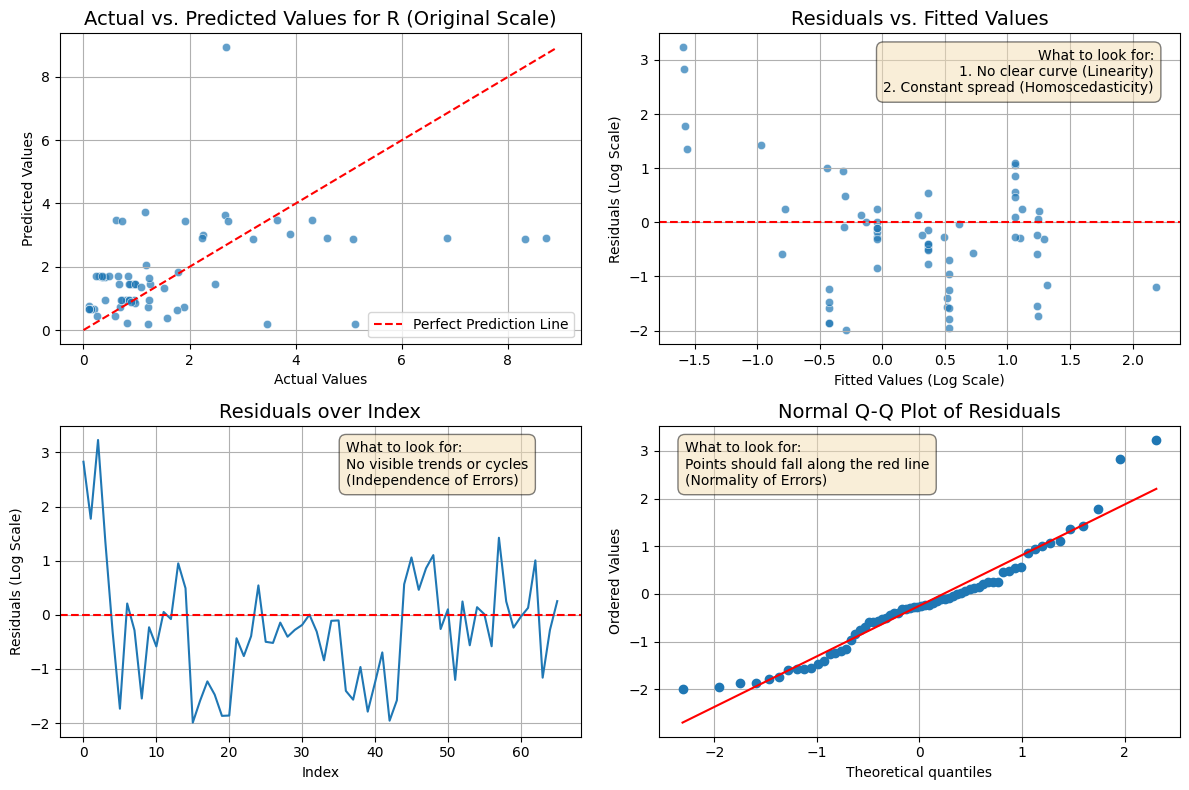

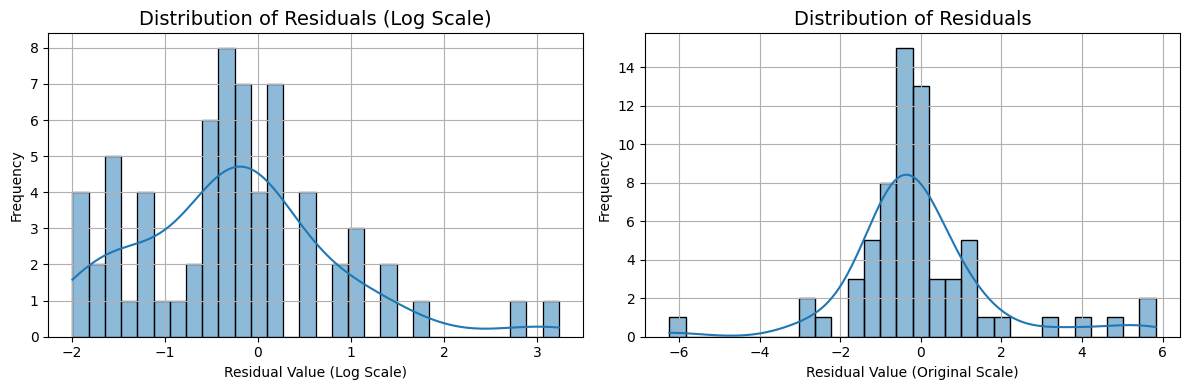


Function 'run_mlr_grid_search' executed in 57.9027 seconds.
Model saved successfully.


In [ ]:
params = {
        'corr_thresh': [0.4, 0.5, 0.6, 0.7],
        'vif_thresh': [1.5, 2.0, 2.5, 5.0, 7, 10],
        'coeff_thresh': [0.02, 0.04, 0.05,  0.06, 0.07]
    }

mlr_r_model, _ , _ = run_mlr_grid_search(target='r', param_grid=params, test_with_test_set=False)
save_model(mlr_r_model, 'mlr_r_model.joblib')

### Analysis of MLR Model for Target: R

This analysis summarizes the results of the Multiple Linear Regression (MLR) model trained to predict the storage coefficient ($R$), following an automated and rigorous feature selection process.

---
#### Model Performance

A hyperparameter grid search was conducted to find the optimal thresholds for feature selection, identifying `corr_thresh: 0.5`, `vif_thresh: 5.0`, and `coeff_thresh: 0.05` as the best parameters.

Despite this rigorous process, the resulting model's performance is exceptionally poor. On the final hold-out test set, the model achieved an **R-squared of only 0.048** on the original scale. This indicates the model explains less than 5% of the variance in $R$, rendering it **no better than a simple mean-value prediction** and unsuitable for practical use. The negative R-squared on the log-transformed data further confirms a complete failure to fit the data. The extremely high Mean Absolute Percentage Error (MAPE) of 133% underscores this lack of predictive power.

---
#### Coefficient Interpretation

While the model has no predictive value, its coefficients offer insight into the limitations of a linear approach for this complex problem. The final model is a mix of hydrologically sound and inconsistent relationships.

* **Consistent with Hydrology:** The model correctly identified that storage ($R$) decreases with steeper slopes (**`main_channel_slope`** and **`basin_slope`**) and increases with the presence of **`pct_wetlands`** and higher **`sinuosity`**.

* **Inconsistent with Hydrology:** The model produced several hydrologically counter-intuitive coefficients. It suggests that higher **`drainage_density`** and more **`pct_barren`** land lead to *increased* storage, which contradicts physical principles where efficient drainage and low-infiltration surfaces should reduce storage.

---
#### Conclusion

The MLR model for $R$ is **unsuitable for prediction**. The combination of extremely low predictive power and several hydrologically inconsistent coefficients provides definitive evidence that a linear model cannot capture the complex dynamics of watershed storage. More advanced, non-linear models are necessary to improve performance.

## Elastic Net - $T_c$


This section details the training of ElasticNet regression model. This model is expected to effectively handle the significant multicollinearity observed in the dataset (VIF > 5), as it linearly combines the L1 (Lasso) and L2 (Ridge) regularization penalties. This approach allows the model to perform automatic feature selection while maintaining stability in the presence of correlated predictors.

***

#### Key Hyperparameters for Tuning

- **Alpha ($\alpha$):** This parameter controls the **overall strength** of the regularization penalty. A higher `alpha` value applies a stronger penalty, pushing all model coefficients more aggressively towards zero, which helps to prevent overfitting.

- **L1 Ratio:** This parameter dictates the **mix** between the L1 and L2 penalties.
    - An `l1_ratio` of `1` is equivalent to a pure **Lasso** model, which is effective for feature selection.
    - An `l1_ratio` of `0` is equivalent to a pure **Ridge** model, which excels at handling correlated features.
    - Values between 0 and 1 create a hybrid model. Given the high multicollinearity, it is hypothesized that the optimal model will give more weight to the Ridge penalty (`l1_ratio` < 0.5).

***

### Tuning Strategy

The optimization of these hyperparameters will be conducted in two stages. A **coarse search** will first be performed across a wide range of values to identify the most promising region. Subsequently, a **fine-grained search** will be executed around the best parameters found in the first stage to pinpoint the optimal configuration.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GroupKFold, GridSearchCV
from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


sklearn.set_config(enable_metadata_routing=True)

@measure_execution_time
def train_and_evaluate_ElasticNet(target,
                                 params,
                                 n_folds=5,
                                 max_iter=10000,
                                 display_test_on_test_set=False):
    """
    Trains and evaluates an ElasticNet Regression model with GridSearchCV and GroupKFold.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        params (dict): The dictionary of parameters to be passed to GridSearchCV.
        n_folds (int): Number of folds for cross-validation.
        max_iter (int): Max number of iterations.
        display_plot (bool): Whether to display diagnostic plots.

    Returns:
        Pipeline: The final trained model pipeline.
    """
    # --- Assume df_train_pool, df_test, create_preprocessor are pre-existing from previous steps ---

    #-------------------------------------------------------------------------------
    ## 1. Preprocessing
    #-------------------------------------------------------------------------------

    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]
    linear_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, features_to_analyze)
    groups = df_train_pool['ws_id']  # Group labels

    # Define data from the training pool
    X_train = df_train_pool[features_to_analyze].copy()

    # Prepare target variable (using log transform)
    y_train = np.log(df_train_pool[target])

    #-------------------------------------------------------------------------------
    ## 2. Training
    #-------------------------------------------------------------------------------
    print(f"\n--- Fitting ElasticNet GridSearchCV Model on {target.upper()}... ---")

    # Define the cross-validator
    cv = GroupKFold(n_splits=n_folds)

    # Create the pipeline with ElasticNet
    model_pipeline = Pipeline(steps=[
        ('preprocessor', linear_preprocessor),
        ('regressor', ElasticNet(max_iter=max_iter, random_state=42))
    ])

    # Define the parameter grid for GridSearchCV
    param_grid = params

    # Create GridSearchCV
    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        return_train_score=True
    )

    # Train the model with GridSearchCV, passing groups for cross-validation
    grid_search.fit(X_train, y_train, groups=groups)
    print("    Training is complete.")
    print("\n--- Pipeline Schema ---")
    display(model_pipeline)

    # Get the best pipeline (fitted model)
    model_pipeline = grid_search.best_estimator_

    #-------------------------------------------------------------------------------
    ## 3. Performance analysis
    #-------------------------------------------------------------------------------

    # GridSearchCV Resutls
    print("\n" + "="*60)
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df.sort_values(by='rank_test_score')
    print("Performance on best CV test:")
    print(results_df[[
        'param_regressor__alpha',
        'param_regressor__l1_ratio',
        'mean_test_score',
        'std_test_score'
    ]].iloc[0])

    if display_test_on_test_set:
      # Prepare the test data
      X_test = df_test[features_to_analyze]

      # Prepare training and test target variables
      y_test_log = np.log(df_test[target])
      y_test_original = df_test[target]

      # Make predictions on the test set
      y_pred_log = model_pipeline.predict(X_test)

      # Inverse transform predictions back to the original scale
      y_pred_original = np.exp(y_pred_log)

      # Evaluation Summary
      log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
      original_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
      hours, minutes = convert_fractional_hours_to_hm(original_metrics['Bias'])

      print(f"\nFinal Model Evaluation on Hold-Out Test Set for target: {target.upper()}\n")
      print("Performance on LOG-TRANSFORMED data:")
      print(f"  R-squared: {log_metrics['R2']:.3f}")
      print(f"  RMSE: {log_metrics['RMSE']:.3f}")
      print(f"  MAPE: {log_metrics['MAPE']:.1f}")
      print(f"  Bias: {log_metrics['Bias']:.3f}")

      print("\nPerformance on ORIGINAL scale data:")
      print(f"  R-squared: {original_metrics['R2']:.3f}")
      print(f"  RMSE: {original_metrics['RMSE']:.3f} hrs")
      print(f"  MAPE: {original_metrics['MAPE']:.1f}")
      print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

      # Get the coefficients and intercept
      model = model_pipeline.named_steps['regressor']
      coefficients = model.coef_
      intercept = model.intercept_

      # Get the feature names AFTER transformation from the preprocessor
      preprocessor = model_pipeline.named_steps['preprocessor']
      try:
          transformed_feature_names = preprocessor.get_feature_names_out()
      except AttributeError:
          transformed_feature_names = features_to_analyze
      df_coeffs = pd.DataFrame({
          'Feature': transformed_feature_names,
          'Coefficient': coefficients
      })
      df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
      df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)
      df_coeffs = df_coeffs[df_coeffs['Abs_Coefficient'] != 0]

      print(f"\n--- Model Coefficients for Target ---")
      print(f"Intercept: {intercept:.4f}\n")
      print(df_coeffs)

      # Retrieve optimal alpha and l1_ratio from GridSearchCV
      optimal_alpha = grid_search.best_params_['regressor__alpha']
      optimal_l1_ratio = grid_search.best_params_['regressor__l1_ratio']

      print(f"\nOptimal alpha: {round(optimal_alpha, 4)}")
      print(f"Optimal l1_ratio: {optimal_l1_ratio}")

      # Distribution of residuals
      residuals_original = y_test_original - y_pred_original
      fig, axes = plt.subplots(1, 2, figsize=(12, 4))
      axes = axes.flatten()

      # Plot - Actual vs. Predicted (Original Scale)
      print("\n")
      sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7, ax=axes[0])
      axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
      axes[0].set_xlabel('Actual Values')
      axes[0].set_ylabel('Predicted Values')
      max_val = max(y_test_original.max(), y_pred_original.max())
      min_val = min(y_test_original.min(), y_pred_original.min())
      axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
      axes[0].legend()
      axes[0].grid(True)

      sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1])  # kde=True adds a kernel density estimate line
      axes[1].set_title(f'Distribution of Residuals', fontsize=14)
      axes[1].set_xlabel('Residual Value (Original Scale)')
      axes[1].set_ylabel('Frequency')
      axes[1].grid(True)
      plt.tight_layout()
      plt.show()

    return model_pipeline

In [41]:
# First stage: coarse list of parameters
print('--- First Stage Parameters Tunning ---')
param_grid_coarse = {
    'regressor__alpha': np.logspace(-4, 3, 15),
    'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
}
print("Coarse Parameter Grid:")
print(param_grid_coarse)

ElasticNet_model_tc_coarse = train_and_evaluate_ElasticNet("tc",
                                  params=param_grid_coarse,
                                  n_folds=5,
                                  max_iter=10000,
                                  display_test_on_test_set=False)

--- First Stage Parameters Tunning ---
Coarse Parameter Grid:
{'regressor__alpha': array([1.00000000e-04, 3.16227766e-04, 1.00000000e-03, 3.16227766e-03,
       1.00000000e-02, 3.16227766e-02, 1.00000000e-01, 3.16227766e-01,
       1.00000000e+00, 3.16227766e+00, 1.00000000e+01, 3.16227766e+01,
       1.00000000e+02, 3.16227766e+02, 1.00000000e+03]), 'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]}
--- Fitting ElasticNet GridSearchCV Model on TC... ---


/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.552e+01, tolerance: 7.923e-03
  model = cd_fast.enet_coordinate_descent(
/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.650e+01, tolerance: 8.024e-03
  model = cd_fast.enet_coordinate_descent(
/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want 

    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x10de06e80>),
                                                                   ['sinuosity',
                                                                    'pct_barren']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'centroidal_flowpath',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'compactness_coefficient',
                                                                    'overland_flow_path_length',
                                                                    'pct_developed',
                                                                    'pct_agriculture',
                                                                    'natural_vs_developed_ratio'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor', ElasticNet(max_iter=10000, random_state=42))])


Performance on best CV test:
param_regressor__alpha       0.100000
param_regressor__l1_ratio    0.500000
mean_test_score             -0.349919
std_test_score               0.148935
Name: 45, dtype: float64

Function 'train_and_evaluate_ElasticNet' executed in 15.5550 seconds.


--- Second  Stage Parameters Tunning ---
Fine Parameter Grid:
{'regressor__alpha': array([0.05011872, 0.05677625, 0.06431812, 0.07286182, 0.08254042,
       0.09350468, 0.10592537, 0.11999597, 0.13593564, 0.15399265,
       0.17444827, 0.19762111, 0.22387211, 0.25361017, 0.28729848,
       0.32546178, 0.36869451, 0.41767005, 0.47315126, 0.53600232,
       0.6072022 , 0.68785991, 0.7792318 , 0.88274107, 1.        ]), 'regressor__l1_ratio': [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]}
--- Fitting ElasticNet GridSearchCV Model on TC... ---
    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x10de06e80>),
                                                                   ['sinuosity',
                                                                    'pct_barren']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'centroidal_flowpath',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'compactness_coefficient',
                                                                    'overland_flow_path_length',
                                                                    'pct_developed',
                                                                    'pct_agriculture',
                                                                    'natural_vs_developed_ratio'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor', ElasticNet(max_iter=10000, random_state=42))])


Performance on best CV test:
param_regressor__alpha       0.072862
param_regressor__l1_ratio    0.650000
mean_test_score             -0.349131
std_test_score               0.147364
Name: 30, dtype: float64

Final Model Evaluation on Hold-Out Test Set for target: TC

Performance on LOG-TRANSFORMED data:
  R-squared: 0.349
  RMSE: 0.381
  MAPE: 14.9
  Bias: -0.065

Performance on ORIGINAL scale data:
  R-squared: 0.345
  RMSE: 4.109 hrs
  MAPE: 34.2
  Bias: -1hrs:35mins

--- Model Coefficients for Target ---
Intercept: 2.3972

                Feature  Coefficient  Abs_Coefficient
14          basin_slope    -0.176525         0.176525
1            pct_forest     0.110294         0.110294
8      drainage_density    -0.078296         0.078296
18     elongation_ratio     0.076155         0.076155
5             pct_water    -0.010293         0.010293
11  centroidal_flowpath     0.006480         0.006480

Optimal alpha: 0.0729
Optimal l1_ratio: 0.65




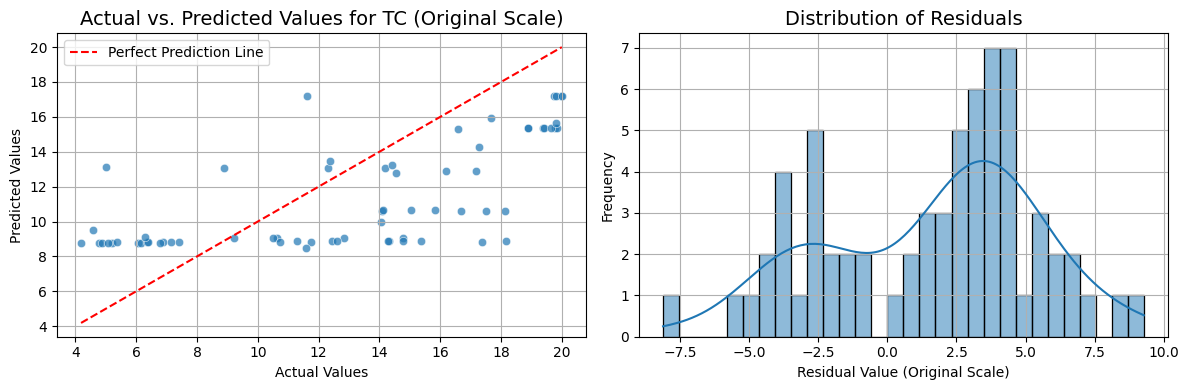


Function 'train_and_evaluate_ElasticNet' executed in 52.7638 seconds.
Model saved successfully.


In [61]:
# Second stage: coarse list of parameters
# First stage: coarse list of parameters
print('--- Second  Stage Parameters Tunning ---')
param_grid_coarse = {
    'regressor__alpha': np.logspace(-1.3, 0, 25),
    'regressor__l1_ratio': [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
}
print("Fine Parameter Grid:")
print(param_grid_coarse)

ElasticNet_model_tc_fine = train_and_evaluate_ElasticNet("tc",
                                  params=param_grid_coarse,
                                  n_folds=5,
                                  max_iter=10000,
                                  display_test_on_test_set=True)
save_model(ElasticNet_model_tc_fine, 'elasticnet_tc_model.joblib')

### Analysis of Elastic Net Regression Model for Target: $T_c$

This section presents the performance and interpretation of the Elastic Net regression model. This model was selected to explicitly address the severe multicollinearity identified in the EDA and observed in the standard MLR model. Its key advantage is the use of L1 and L2 regularization to stabilize coefficients and perform automatic feature selection.

---
#### Overall Model Performance

The Elastic Net model represents a **significant improvement** over the manually feature-selected Multiple Linear Regression (MLR) model. The optimal hyperparameters, identified via a grid search cross-validation, were an `alpha` of 0.073 and an `l1_ratio` of 0.65.

On the hold-out test set, the final model achieved an **R-squared of 0.345** on the original scale. This is a substantial increase from the 0.199 R-squared of the MLR model, indicating that the Elastic Net's regularized approach explains a larger portion of the variance in the time of concentration. The Root Mean Squared Error (RMSE) was also reduced from 4.54 hours (MLR) to **4.11 hours**, signifying a more accurate model. While the performance is still modest, it confirms that regularization is a superior strategy for handling this dataset compared to manual feature removal.

---
#### Interpretation of Model Coefficients

The L1 component of the Elastic Net regularization performed automatic feature selection, resulting in a parsimonious model with only six non-zero coefficients. The regularized model produced a more stable and hydrologically sound set of relationships compared to the standard MLR.

* **Hydrologically Consistent Predictors:** The model successfully identified several physically sound relationships:
    * **`basin_slope` (-0.177):** As the most influential predictor, its negative coefficient is **hydrologically correct**. It indicates that watersheds with steeper average slopes have a faster response time (a lower $T_c$).
    * **`pct_forest` (+0.110):** The positive coefficient is sound, indicating that increased forest cover slows runoff and increases the time of concentration.
    * **`drainage_density` (-0.078):** The negative coefficient correctly implies that a more efficient drainage network leads to a faster response time (lower $T_c$).

* **Counter-intuitive Predictor:**
    * **`elongation_ratio` (+0.076):** This coefficient is **counter-intuitive**. A higher elongation ratio signifies a more circular basin, which should drain more efficiently and lead to a *lower* $T_c$. The model's positive coefficient suggests the opposite. The exploratory analysis ([see here](15_exploratory_data_analysis.ipynb)) indicates that Tc grows with elongation ratio. This indicates that even with regularization, the linear model struggles to perfectly capture the complex influence of basin shape, likely due to interactions with other variables.

---
#### Conclusions

The Elastic Net model is a clear and significant improvement over the standard MLR. Its automated regularization and feature selection process produced a more stable, more accurate, and more hydrologically interpretable model.

However, the model's overall predictive power remains limited (R-squared ≈ 0.35), and the persistence of a hydrologically inconsistent coefficient for `elongation_ratio` suggests that a linear framework is not sufficient to fully describe the complex, non-linear interactions governing watershed response. This result reinforces the expectation that non-linear models like Random Forest and SVM are likely to provide superior performance.

## Elastic Net- $R$

In [65]:
# First stage: coarse list of parameters
print('--- First Stage Parameters Tunning ---')
param_grid_coarse = {
    'regressor__alpha': np.logspace(-4, 3, 15),
    'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
}
print("Coarse Parameter Grid:")
print(param_grid_coarse)

ElasticNet_model_r_coarse = train_and_evaluate_ElasticNet("r",
                                  params=param_grid_coarse,
                                  n_folds=5,
                                  max_iter=10000,
                                  display_test_on_test_set=False)

--- First Stage Parameters Tunning ---
Coarse Parameter Grid:
{'regressor__alpha': array([1.00000000e-04, 3.16227766e-04, 1.00000000e-03, 3.16227766e-03,
       1.00000000e-02, 3.16227766e-02, 1.00000000e-01, 3.16227766e-01,
       1.00000000e+00, 3.16227766e+00, 1.00000000e+01, 3.16227766e+01,
       1.00000000e+02, 3.16227766e+02, 1.00000000e+03]), 'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]}

--- Fitting ElasticNet GridSearchCV Model on R... ---


/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.318e+01, tolerance: 2.915e-02
  model = cd_fast.enet_coordinate_descent(
/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.431e+01, tolerance: 3.473e-02
  model = cd_fast.enet_coordinate_descent(
/Users/alan/Data Science Projects/ML-ModClark-IUH-Model/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want 

    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x10de06e80>),
                                                                   ['form_factor',
                                                                    'elongation_ratio',
                                                                    'sinuosity',
                                                                    'pct_developed']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'basin_relief',
                                                                    'compactness_coefficient',
                                                                    'relief_ratio',
                                                                    'overland_flow_path_length',
                                                                    'pct_agriculture',
                                                                    'pct_grass_scrub',
                                                                    'pct_wetlands',
                                                                    'pct_water',
                                                                    'pct_barren',
                                                                    'natural_vs_developed_ratio'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor', ElasticNet(max_iter=10000, random_state=42))])


Performance on best CV test:
param_regressor__alpha       1.000000
param_regressor__l1_ratio    0.010000
mean_test_score             -1.537743
std_test_score               0.559918
Name: 56, dtype: float64

Function 'train_and_evaluate_ElasticNet' executed in 38.5495 seconds.


--- Second Stage Parameters Tunning ---
Coarse Parameter Grid:
{'regressor__alpha': array([0.1       , 0.11437559, 0.13081775, 0.14962357, 0.17113283,
       0.19573418, 0.22387211, 0.25605504, 0.29286446, 0.33496544,
       0.38311868, 0.43819424, 0.50118723, 0.57323584, 0.65564185,
       0.74989421, 0.8576959 , 0.98099471, 1.12201845, 1.28331519,
       1.46779927, 1.67880402, 1.92014194, 2.1961736 , 2.51188643]), 'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]}

--- Fitting ElasticNet GridSearchCV Model on R... ---
    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x10de06e80>),
                                                                   ['form_factor',
                                                                    'elongation_ratio',
                                                                    'sinuosity',
                                                                    'pct_developed']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'basin_relief',
                                                                    'compactness_coefficient',
                                                                    'relief_ratio',
                                                                    'overland_flow_path_length',
                                                                    'pct_agriculture',
                                                                    'pct_grass_scrub',
                                                                    'pct_wetlands',
                                                                    'pct_water',
                                                                    'pct_barren',
                                                                    'natural_vs_developed_ratio'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor', ElasticNet(max_iter=10000, random_state=42))])


Performance on best CV test:
param_regressor__alpha       0.980995
param_regressor__l1_ratio    0.010000
mean_test_score             -1.537684
std_test_score               0.558807
Name: 119, dtype: float64

Final Model Evaluation on Hold-Out Test Set for target: R

Performance on LOG-TRANSFORMED data:
  R-squared: 0.346
  RMSE: 0.854
  MAPE: 118.0
  Bias: 0.083

Performance on ORIGINAL scale data:
  R-squared: 0.056
  RMSE: 1.793 hrs
  MAPE: 88.4
  Bias: 0hrs:26mins

--- Model Coefficients for Target ---
Intercept: 0.1732

                       Feature  Coefficient  Abs_Coefficient
2              pct_agriculture     0.118935         0.118935
5                    pct_water    -0.116545         0.116545
15                basin_relief     0.101317         0.101317
14                 basin_slope    -0.099118         0.099118
3              pct_grass_scrub    -0.093241         0.093241
6                   pct_barren    -0.090539         0.090539
1                   pct_forest    -0.08964

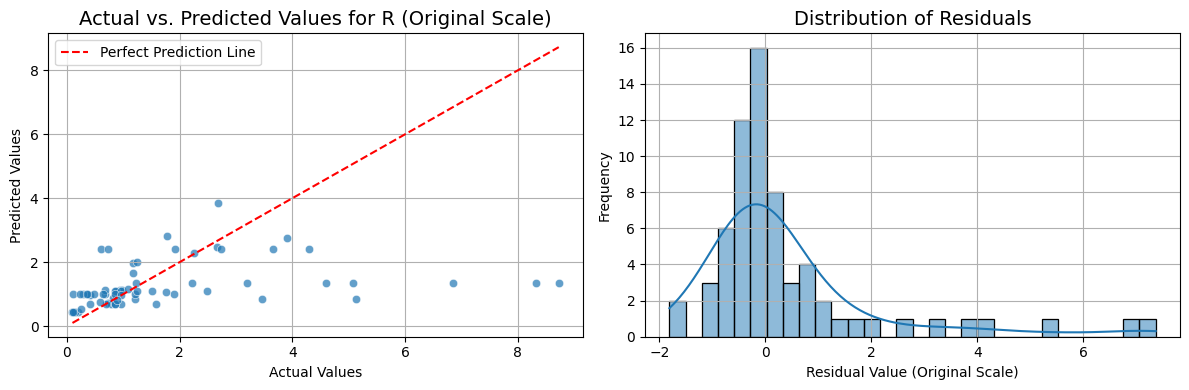


Function 'train_and_evaluate_ElasticNet' executed in 52.2480 seconds.
Model saved successfully.


In [74]:
# Second stage: finner list of parameters
print('--- Second Stage Parameters Tunning ---')
param_grid_coarse = {
    'regressor__alpha': np.logspace(-1, 0.4, 25),
    'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
}
print("Coarse Parameter Grid:")
print(param_grid_coarse)

ElasticNet_r_model = train_and_evaluate_ElasticNet("r",
                                  params=param_grid_coarse,
                                  n_folds=5,
                                  max_iter=10000,
                                  display_test_on_test_set=True)
save_model(ElasticNet_r_model, 'elasticnet_r_model.joblib')

### Analysis of Elastic Net Regression Model for Target: R

Likewise the MLR for $T_c$, this analysis evaluates the Elastic Net regression model, which was employed to address the severe multicollinearity issues and poor performance observed in the standard MLR model for predicting the storage coefficient ($R$).

---
#### Overall Model Performance

Despite the use of regularization, the Elastic Net model's performance is **extremely poor**, rendering it unsuitable for predictive tasks.

On the final hold-out test set, the model achieved an **R-squared of only 0.056** on the original data scale. This indicates that the model explains a negligible 5.6% of the variance in $R$, offering virtually no predictive advantage over a simple mean-based estimate.

A significant discrepancy was observed between the performance on the log-transformed scale ($R^2=0.346$) and the original scale. This drastic drop-off is a classic symptom of a model that may capture the general trend for low-value data points but fails significantly when predicting higher-magnitude values of $R$, as clearly seen from the 'Actual vs Predicted' plot . These large errors are then amplified by the exponential back-transformation, resulting in the poor overall score. The high Mean Absolute Percentage Error (MAPE) of 88.4% further confirms the model's lack of precision.

---
#### Interpretation of Hyperparameters and Coefficients

The grid search cross-validation selected a high regularization strength (`alpha`: 0.981) and a very low L1 ratio (`l1_ratio`: 0.01). This indicates that the optimal model relied almost exclusively on L2 (Ridge) regularization, which shrinks coefficients rather than eliminating them. This suggests that while many features are noisy and correlated, the model determined that most possess some small predictive signal worth retaining.

However, an examination of the resulting coefficients reveals that the model is still plagued by instabilities and fails to learn hydrologically sound relationships:

* **Hydrologically Inconsistent Coefficients:** The model produced several coefficients that contradict fundamental hydrologic principles.
    * **`basin_relief`** has a positive coefficient (+0.10), incorrectly implying that watersheds with higher relief have *more* storage.
    * **`pct_water`** has a negative coefficient (-0.12), incorrectly suggesting that a greater presence of open water (lakes, reservoirs) *decreases* storage.
    * These implausible coefficients are clear indicators that even with strong regularization, the linear model cannot disentangle the complex, correlated effects within the feature set.

* **Plausible Relationships:** The model did correctly identify some expected trends, such as storage decreasing with a steeper **`basin_slope`** (-) and increasing with higher **`sinuosity`** (+).

---
#### Conclusions

The Elastic Net model, while theoretically better suited for this dataset than a standard MLR, ultimately fails to produce a useful predictive model for the storage coefficient $R$.

The combination of extremely poor predictive performance and the persistence of several hydrologically inconsistent coefficients provides definitive evidence that a linear modeling framework is incapable of capturing the complex, non-linear dynamics of watershed storage (at leat, as long as seen in our dataset). This result strongly motivates the use of **non-linear models like Support Vector Regression and Random Forest**, which are better equipped to handle the complex interactions inherent in this problem.

## Support Vector Regression (SVR)

This section outlines the training of the Support Vector Regression (SVR) model. The model's key hyperparameters are optimized to balance predictive accuracy with generalization performance.

- **C (Regularization Parameter):** Controls the trade-off between model simplicity and fitting the training data precisely. A **low `C`** value increases regularization, allowing for more error tolerance and creating a simpler model. A **high `C`** reduces regularization, forcing the model to fit the data more strictly, which can risk overfitting.
    - **Range:** Typically tuned on a logarithmic scale (e.g., `[0.1, 1, 10, 100, 1000]`).

- **Kernel:** Defines the transformation applied to the data to model non-linear relationships.
    - **Values:** A discrete set, most commonly `['linear', 'rbf', 'poly']`.
        - `'linear'`: Assumes a linear relationship.
        - `'rbf'` (Radial Basis Function): Captures complex, non-linear patterns.
        - `'poly'` (Polynomial): Models polynomial features.

- **Epsilon ($\epsilon$):** Defines the width of the margin of tolerance (the "tube") around the regression line. Data points falling within this tube are not penalized, which makes the model less sensitive to minor fluctuations and noise.
    - **Range:** Typically small positive values (e.g., `[0.01, 0.05, 0.1, 0.2]`).

- **Gamma ($\gamma$):** Specifies the influence of a single training example, which is critical for the `'rbf'` and `'poly'` kernels. A **low `gamma`** means points have a far-reaching influence, resulting in a smoother model. A **high `gamma`** means each point has a very localized influence, leading to a more complex and potentially overfit model.
    - **Range:** Can be a specific value on a logarithmic scale (e.g., `[0.001, 0.01, 0.1]`) or scikit-learn's automated settings, `'scale'` (default) or `'auto'`.

These hyperparameters are tuned using a two-stage grid search with cross-validation. An initial **coarse search** identifies the most promising value ranges, followed by a **fine-grained search** to pinpoint the optimal combination.

### $T_c$

In [79]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

@measure_execution_time
def train_and_evaluate_SVR(target,
                            params,
                            n_folds = 5,
                            display_test_on_test_set = False):
    """
    Trains and evaluates a Support Vector Regression (SVR) model with grid search and cross-validation.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        params (dict): Dictionary of parameters to be passed to the model.
        n_folds (int): Number of cross-validation folds.
        display_test_on_test_set (bool): Whether to display result on final hold-out test set.

    Returns:
        Pipeline: The final trained SVR model pipeline.
    """

    # --- Assume df_train_pool and df_test are pre-existing from previous steps ---

    #-------------------------------------------------------------------------------
    ## 1. Preprocessing
    #-------------------------------------------------------------------------------
    # Define features and target
    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]

    X_train = df_train_pool[features_to_analyze].copy()
    y_train = np.log(df_train_pool[target])
    groups = df_train_pool['ws_id']  # Group labels

    # Define pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    # Define parameter grid
    param_grid = params

    # Define group-aware cross-validator
    group_kfold = GroupKFold(n_splits=n_folds)

    # Grid search with group-aware CV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=group_kfold,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    #-------------------------------------------------------------------------------
    ## 2. Train
    #-------------------------------------------------------------------------------

    print(f"\n--- Fitting Support Vector Regression Model on {target.upper()} with Grid Search and Cross Validation... ---")
    grid_search.fit(X_train, y_train, groups=groups)
    print('Fitting is complete.')
    print("\n--- Pipeline Schema ---")
    display(pipeline)

    #-------------------------------------------------------------------------------
    ## 3. Performance analysis
    #-------------------------------------------------------------------------------

    # Evaluation Summary
    print("\n" + "="*60)
    print("\nBest Parameters:", grid_search.best_params_)

    # GridSearchCV Results
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df.sort_values(by='rank_test_score')
    display_cols = ['mean_test_score', 'std_test_score']

    print("\nPerformance on best CV test:")
    print(results_df[display_cols].iloc[0])

    # Retrieve best model
    best_model = grid_search.best_estimator_
    if display_test_on_test_set:

      # Prepare the test data
      X_test = df_test[features_to_analyze]

      # Prepare training and test target variables
      y_train = np.log(df_train_pool[target])
      y_test_log = np.log(df_test[target])
      y_test_original = df_test[target]

      # Evaluate on test set
      y_pred_log = best_model.predict(X_test)
      y_pred_original = np.exp(y_pred_log)

      # Calculate and print  metrics
      log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
      original_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
      hours, minutes = convert_fractional_hours_to_hm(original_metrics['Bias'])

      print(f"\n--- Evaluation on Hold Out Test Set for target: {target.upper()} ---")
      print("\nPerformance on LOG-TRANSFORMED data:")
      print(f"  R-squared: {log_metrics['R2']:.3f}")
      print(f"  RMSE: {log_metrics['RMSE']:.3f}")
      print(f"  MAPE: {log_metrics['MAPE']:.1f}")
      print(f"  Bias: {log_metrics['Bias']:.3f}")

      print("\nPerformance on ORIGINAL scale data:")
      print(f"  R-squared: {original_metrics['R2']:.3f}")
      print(f"  RMSE: {original_metrics['RMSE']:.3f} hrs")
      print(f"  MAPE: {original_metrics['MAPE']:.1f}")
      print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

      # Distribution of residuals
      residuals_original = y_test_original - y_pred_original
      fig, axes = plt.subplots(1, 2, figsize=(12, 4))
      axes = axes.flatten()

      # Plot - Actual vs. Predicted (Original Scale)
      print("\n")
      sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7, ax=axes[0])
      axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
      axes[0].set_xlabel('Actual Values')
      axes[0].set_ylabel('Predicted Values')
      max_val = max(y_test_original.max(), y_pred_original.max())
      min_val = min(y_test_original.min(), y_pred_original.min())
      axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
      axes[0].legend()
      axes[0].grid(True)

      sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1])  # kde=True adds a kernel density estimate line
      axes[1].set_title(f'Distribution of Residuals', fontsize=14)
      axes[1].set_xlabel('Residual Value (Original Scale)')
      axes[1].set_ylabel('Frequency')
      axes[1].grid(True)
      plt.tight_layout()
      plt.show()

      #-------------------------------------------------------------------------------
      ## 3. Feature importance analysis
      #-------------------------------------------------------------------------------

      # Compute permutation importance
      results = permutation_importance(best_model, X_test, y_test_log, scoring='neg_mean_squared_error', n_repeats=30, random_state=42)
      importance = results.importances_mean
      feature_names = X_test.columns

      print('\n--- Feature Importance Analysis ---')
      # Create a DataFrame for easier handling and sorting
      importance_df = pd.DataFrame({
          'Feature': feature_names,
          'Importance': importance
      }).sort_values(by='Importance', ascending=False)

      print(importance_df.head(5))

      # Plot feature importance
      plt.figure(figsize=(10, 6))
      bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
      plt.xlabel('Mean Importance Score')
      plt.title('Feature Importance via Permutation (SVR)')
      plt.gca().invert_yaxis()  # Highest importance at the top
      plt.grid(axis='x', linestyle='--', alpha=0.7)

      # Annotate bars with importance values
      for bar in bars:
          width = bar.get_width()
          plt.text(width + 0.001, bar.get_y() + max(bar.get_height())*1.001, f'{width:.4f}', va='center')

      plt.tight_layout()
      plt.show()

    return best_model


In [82]:
param_grid_coarse = {
    'svr__kernel': ['linear', 'rbf', 'poly'],
    'svr__C': np.logspace(-2, 3, 10),
    'svr__gamma': np.logspace(-4, 1, 10),
    'svr__epsilon':  np.logspace(-2, 0, 10)
}

# First stage: coarse list of parameters
print('--- First Stage Parameters Tunning ---')
print(param_grid_coarse)

SVR_tc_model_coarse_params = train_and_evaluate_SVR('tc',
                                                    params = param_grid_coarse,
                                                    n_folds = 5,
                                                    display_test_on_test_set=False)


--- First Stage Parameters Tunning ---
{'svr__kernel': ['linear', 'rbf', 'poly'], 'svr__C': array([1.00000000e-02, 3.59381366e-02, 1.29154967e-01, 4.64158883e-01,
       1.66810054e+00, 5.99484250e+00, 2.15443469e+01, 7.74263683e+01,
       2.78255940e+02, 1.00000000e+03]), 'svr__gamma': array([1.00000000e-04, 3.59381366e-04, 1.29154967e-03, 4.64158883e-03,
       1.66810054e-02, 5.99484250e-02, 2.15443469e-01, 7.74263683e-01,
       2.78255940e+00, 1.00000000e+01]), 'svr__epsilon': array([0.01      , 0.01668101, 0.02782559, 0.04641589, 0.07742637,
       0.12915497, 0.21544347, 0.35938137, 0.59948425, 1.        ])}

--- Fitting Support Vector Regression Model on TC with Grid Search and Cross Validation... ---
Fitting is complete.

--- Pipeline Schema ---


Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])



Best Parameters: {'svr__C': np.float64(278.2559402207126), 'svr__epsilon': np.float64(0.5994842503189409), 'svr__gamma': np.float64(0.001291549665014884), 'svr__kernel': 'poly'}

Performance on best CV test:
mean_test_score   -0.387687
std_test_score     0.138152
Name: 2648, dtype: float64

Function 'train_and_evaluate_SVR' executed in 41 minutes and 45.8288 seconds.



--- Second Stage Parameters Tunning ---
{'svr__kernel': ['poly', 'rbf'], 'svr__C': array([  1.        ,   1.93069773,   3.72759372,   7.19685673,
        13.89495494,  26.82695795,  51.79474679, 100.        ]), 'svr__degree': [2, 3, 4], 'svr__gamma': array([0.001     , 0.0019307 , 0.00372759, 0.00719686, 0.01389495,
       0.02682696, 0.05179475, 0.1       ]), 'svr__epsilon': [0.3, 0.4, 0.5, 0.6, 0.7]}

--- Fitting Support Vector Regression Model on TC with Grid Search and Cross Validation... ---
Fitting is complete.

--- Pipeline Schema ---


Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])



Best Parameters: {'svr__C': np.float64(13.894954943731374), 'svr__degree': 3, 'svr__epsilon': 0.6, 'svr__gamma': np.float64(0.003727593720314938), 'svr__kernel': 'poly'}
Performance on ORIGINAL Scale TRAINING SET:
  R-squared: -0.086
  RMSE: 5.998

--- Evaluation on Hold Out Test Set for target: TC ---


Performance on LOG-TRANSFORMED data:
  R-squared: -0.018
  RMSE: 0.477
  MAPE: 19.0
  Bias: -0.118

Performance on ORIGINAL scale data:
  R-squared: -0.185
  RMSE: 5.526 hrs
  MAPE: 44.0
  Bias: -2hrs:30mins




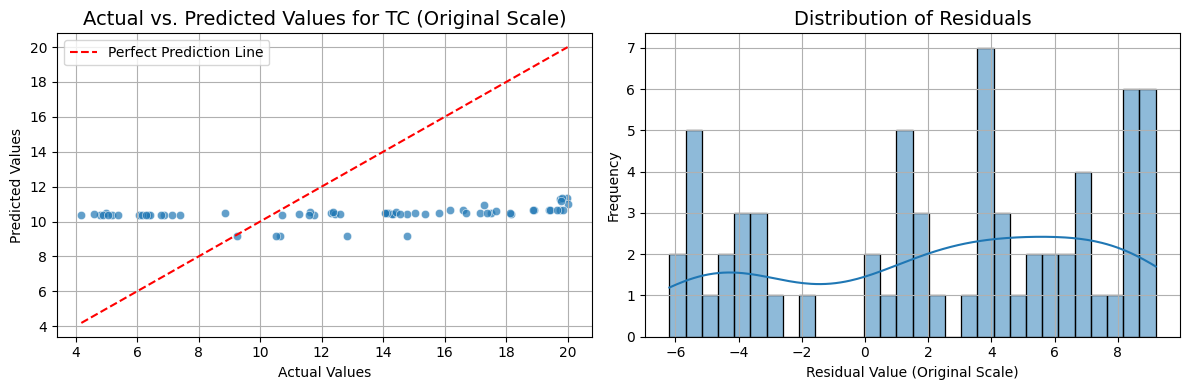


--- Feature Importance Analysis ---
              Feature  Importance
15       basin_relief    0.002963
1          pct_forest    0.002700
3     pct_grass_scrub    0.002264
0       pct_developed    0.002260
20  ruggedness_number    0.001961


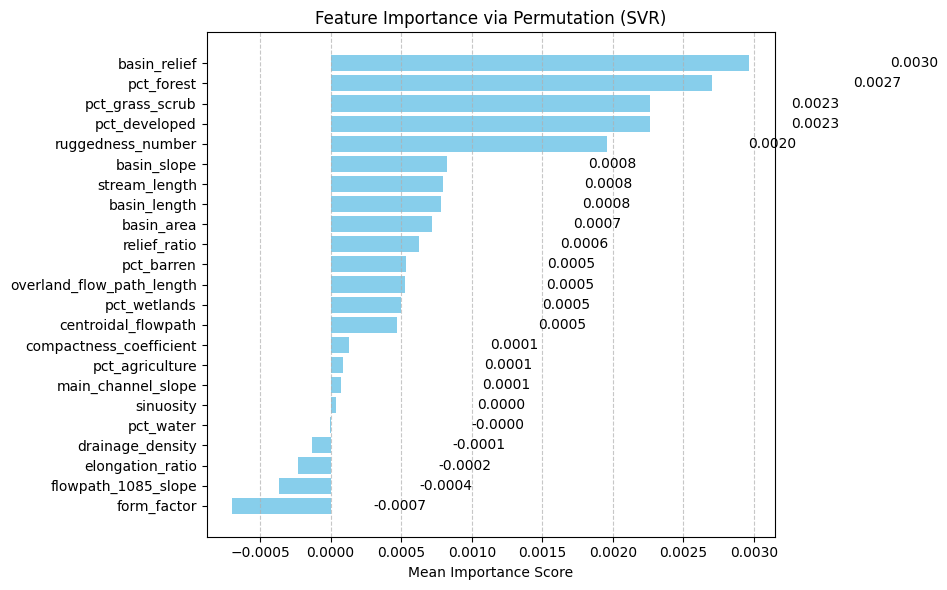

In [ ]:
# Second stage: finer list of parameters
param_grid_fine = {
    'svr__kernel': ['poly', 'rbf'],
    'svr__C': np.logspace(0, 2, 10),
    'svr__degree': [2, 3, 4], # Since the best model in first stage was polynomial
    'svr__gamma': np.logspace(-3, -1, 10),
    'svr__epsilon': [0.3, 0.4, 0.5, 0.6, 0.7]
}
print('--- Second Stage Parameters Tunning ---')
print(param_grid_fine)
SVR_tc_model_final = train_and_evaluate_SVR('tc',
                                            params = param_grid_fine,
                                            n_folds = 5,
                                            display_test_on_test_set=True)


In [ ]:
# Save trained model
save_model(SVR_tc_model, 'SVR_model_tc.joblib')

## Random Forest Regression

This section outlines the training of Random Forest Regressor, an ensemble learning method that operates by constructing a multitude of decision trees at training time. For a regression task, the final prediction is the average of the predictions from all individual trees, which helps to improve accuracy and control overfitting.

The model's performance is highly dependent on its hyperparameters, which are tuned to find the optimal balance between model complexity and generalization.

***

### Key Hyperparameters for Tuning

-   **`n_estimators`**: The number of decision trees in the forest. Increasing the number of trees generally leads to a more robust and stable model, as it reduces variance. However, this comes at the cost of longer training times, and there is a point of diminishing returns where adding more trees provides no significant benefit.

-   **`max_depth`**: The maximum depth allowed for each individual tree. This parameter is a primary way to control model complexity. A **deeper tree** can capture more complex patterns and interactions in the data but is also more likely to overfit. A **shallower tree** is more general but may fail to capture important patterns (underfitting).

-   **`min_samples_split`**: The minimum number of data points required in a node before it can be split. A **higher value** prevents the model from learning relationships that might be specific to a very small group of samples, thus making the model more general and resistant to noise.

-   **`min_samples_leaf`**: The minimum number of data points that must be present in a leaf node (a final decision node). Similar to `min_samples_split`, a **higher value** creates a more generalized model by ensuring that each final prediction is based on a reasonably large number of samples.

-   **`max_features`**: The number of features to consider when looking for the best split at each node. Limiting the number of features increases the diversity among the trees in the forest, which can significantly improve the model's overall performance by reducing correlation between the trees.

***

### Tuning Strategy

These hyperparameters will be optimized using a grid search with cross-validation. This process will systematically test different combinations of the values above to identify the configuration that yields the best predictive performance.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def train_and_evaluate_RandomForest(target,
                                     params,
                                     n_folds=5,
                                     display_test_on_test_set=False,
                                     df_train_pool=None,
                                     df_test=None):
    """
    Trains and evaluates a Random Forest Regressor model with grid search and cross-validation.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        params (dict): Dictionary of parameters to be passed to the model for grid search.
        n_folds (int): Number of cross-validation folds.
        display_test_on_test_set (bool): Whether to display results on the final hold-out test set.
        df_train_pool (pd.DataFrame): The training data.
        df_test (pd.DataFrame): The hold-out test data.

    Returns:
        Pipeline: The final trained Random Forest model pipeline.
    """

    # --- Assume df_train_pool and df_test are pre-existing and passed as arguments ---
    if df_train_pool is None or df_test is None:
        raise ValueError("df_train_pool and df_test must be provided.")

    #-------------------------------------------------------------------------------
    ## 1. Preprocessing
    #-------------------------------------------------------------------------------
    # Define features and target
    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]

    X_train = df_train_pool[features_to_analyze].copy()
    y_train = np.log(df_train_pool[target])
    groups = df_train_pool['ws_id']  # Group labels for cross-validation

    # Define pipeline. StandardScaler is not needed for Random Forest.
    pipeline = Pipeline([
        ('rf', RandomForestRegressor(random_state=42)) # Using a random_state for reproducibility
    ])

    # Define parameter grid from user input
    param_grid = params

    # Define group-aware cross-validator
    group_kfold = GroupKFold(n_splits=n_folds)

    # Grid search with group-aware CV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=group_kfold,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    #-------------------------------------------------------------------------------
    ## 2. Train
    #-------------------------------------------------------------------------------

    print(f"\n--- Fitting Random Forest Regression Model on {target.upper()} with Grid Search and Cross Validation... ---")
    grid_search.fit(X_train, y_train, groups=groups)
    print('Fitting is complete.')
    print("\n--- Pipeline Schema ---")
    display(pipeline)

    #-------------------------------------------------------------------------------
    ## 3. Performance analysis
    #-------------------------------------------------------------------------------

    # Evaluation Summary
    print("\n" + "="*60)
    print("\nBest Parameters:", grid_search.best_params_)

    # GridSearchCV Results
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df.sort_values(by='rank_test_score')

    # Dynamically find parameter columns to display
    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    display_cols = param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']

    print("\nPerformance on best 5 CV tests:")
    print(results_df[display_cols].head(5))

    best_model = grid_search.best_estimator_

    if display_test_on_test_set:
      # Prepare the test data
      X_test = df_test[features_to_analyze]

      # Prepare training and test target variables
      y_test_log = np.log(df_test[target])
      y_test_original = df_test[target]

      y_pred_log = best_model.predict(X_test)
      y_pred_original = np.exp(y_pred_log)

      # Calculate and print metrics
      log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
      original_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
      hours, minutes = convert_fractional_hours_to_hm(original_metrics['Bias'])

      print(f"\n--- Evaluation on Hold Out Test Set for target: {target.upper()} ---")
      print("\nPerformance on LOG-TRANSFORMED data:")
      print(f"  R-squared: {log_metrics['R2']:.3f}")
      print(f"  RMSE: {log_metrics['RMSE']:.3f}")
      print(f"  MAPE: {log_metrics['MAPE']:.1f}")
      print(f"  Bias: {log_metrics['Bias']:.3f}")

      print("\nPerformance on ORIGINAL scale data:")
      print(f"  R-squared: {original_metrics['R2']:.3f}")
      print(f"  RMSE: {original_metrics['RMSE']:.3f} hrs")
      print(f"  MAPE: {original_metrics['MAPE']:.1f}")
      print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

      # Distribution of residuals
      residuals_original = y_test_original - y_pred_original
      fig, axes = plt.subplots(1, 2, figsize=(12, 4))
      axes = axes.flatten()

      # Plot - Actual vs. Predicted (Original Scale)
      sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7, ax=axes[0])
      axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
      axes[0].set_xlabel('Actual Values')
      axes[0].set_ylabel('Predicted Values')
      max_val = max(y_test_original.max(), y_pred_original.max())
      min_val = min(y_test_original.min(), y_pred_original.min())
      axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
      axes[0].legend()
      axes[0].grid(True)

      sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1])
      axes[1].set_title(f'Distribution of Residuals', fontsize=14)
      axes[1].set_xlabel('Residual Value (Original Scale)')
      axes[1].set_ylabel('Frequency')
      axes[1].grid(True)
      plt.tight_layout()
      plt.show()

      #-------------------------------------------------------------------------------
      ## 4. Feature importance analysis (using built-in feature importances)
      #-------------------------------------------------------------------------------

      # Access the fitted Random Forest model from the pipeline
      rf_model = best_model.named_steps['rf']

      # Get feature importances
      importances = rf_model.feature_importances_
      feature_names = X_train.columns

      print('\n--- Feature Importance Analysis (from model) ---')
      # Create a DataFrame for easier handling and sorting
      importance_df = pd.DataFrame({
          'Feature': feature_names,
          'Importance': importances
      }).sort_values(by='Importance', ascending=False)

      print(importance_df.head(5))

      # Plot feature importance
      plt.figure(figsize=(10, 6))
      bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
      plt.xlabel('Importance Score')
      plt.title('Feature Importance (Random Forest)')
      plt.gca().invert_yaxis()  # Highest importance at the top
      plt.grid(axis='x', linestyle='--', alpha=0.7)

      # Annotate bars with importance values
      for bar in bars:
          width = bar.get_width()
          plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')

      plt.tight_layout()
      plt.show()

    return best_model


--- Preprocessing: scaling features, created grid and setting up cross validation ---

--- Fitting Support Vector Regression Model on TC with Grid Search and Cross Validation... ---
Fitting is complete.

--- Pipeline Schema ---


Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])



--- Evaluation on Hold Out Test Set for target: TC ---

Best Parameters: {'svr__C': 0.0039, 'svr__epsilon': 0.14, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
Performance on LOG-TRANSFORMED data:
  R-squared: 0.445
  RMSE: 0.352
  MAPE: 13.5
  Bias: -0.015

Performance on ORIGINAL scale data:
  R-squared: 0.513
  RMSE: 3.543 hrs
  MAPE: 31.3
  Bias: 0hrs:55mins


In [ ]:
# Coarse parameter grid for RandomForestRegressor
param_grid_coarse_rf = {
    'rf__n_estimators': [100, 200, 300], # Number of trees
    'rf__max_depth': [10, 20, None], # 'None' means nodes expand until all leaves are pure
    'rf__min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'rf__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'rf__max_features': ['sqrt', 0.33] # 'sqrt' is a common default, 0.33 tests a fraction
}

rf_model = train_and_evaluate_RandomForest(
     target='tc',
     params=param_grid_coarse_rf,
     display_test_on_test_set=True,
     df_train_pool=df_train_pool,
     df_test=df_test
)